In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import tx_rx_system

## Anàlisi de l'Emisor

En aquesta etapa del projecte, ens centrem en el comportament del senyal enviat pel nostre LED driver. L'objectiu és validar que el circuit respon correctament a la freqüència de treball.

### 1. Generació del Senyal de Pols (1 kHz)

Per començar l'anàlisi, simulem la transmissió d'un senyal quadrat. Aquest senyal representa les dades digitals que volem transmetre.
Paràmetres de la Simulació:
- Freqüència: $1\text{ kHz}$ (període de $1\text{ ms}$).
- Amplitud: $3.3\text{ V}$ (nivell lògic estàndard).
- Cicle de treball (Duty Cycle): $50\%$.

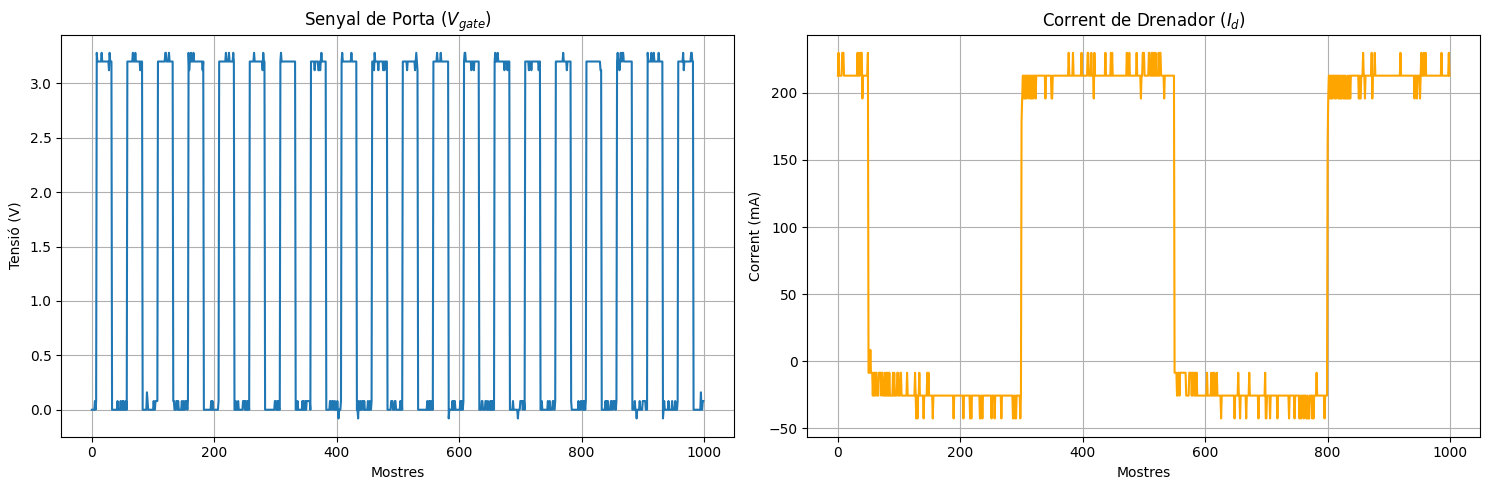

In [5]:
tx_rx_system.convertir_senyal_osciloscopi("fitxers/1kHz_V_gate.csv", "fitxers/1kHz_V_gate_neta.csv", channels=1)
tx_rx_system.convertir_senyal_osciloscopi("fitxers/1kHz_Id.csv", "fitxers/1kHz_Id_neta.csv", channels=1)

signal_gate = np.loadtxt("fitxers/1kHz_V_gate_neta.csv", delimiter=',')
v_mesurada = np.loadtxt("fitxers/1kHz_Id_neta.csv", delimiter=',')

resistencia = 4.7  # Ohms -- L'has mesurada?! 
signal_Id = ((5 - v_mesurada) / resistencia) * 1000  # Els 5V els has mesurat? A tenir en compte: Això és mesura indirecte de la intensitat del corrent elèctric, la precisió depèn de la precisió d' V i R

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(signal_gate[:1000])
ax1.set_title("Senyal de Porta ($V_{gate}$)")
ax1.set_xlabel("Mostres") # Si acaba a la memòria, estaria bé passar de mostres a temps
ax1.set_ylabel("Tensió (V)")
ax1.grid(True)

ax2.plot(signal_Id[:1000], color='orange')
ax2.set_title("Corrent de Drenador ($I_d$)")
ax2.set_xlabel("Mostres")
ax2.set_ylabel("Corrent (mA)")
ax2.grid(True)
plt.tight_layout()
plt.show()

#### Interpretació del resultat

### 2. Generació del Senyal de Pols (1 MHz)

En aquesta secció simulem la transmissió d'un senyal quadrat al sistema.

- Freqüència: 1 MHz.
- Amplitud: 3.3V.
- Objectiu: Demostrar que a aquesta freqüència, el voltatge $V_{gate}$ no té prou temps per carregar-se i assolir pràcticament els 3.3V.


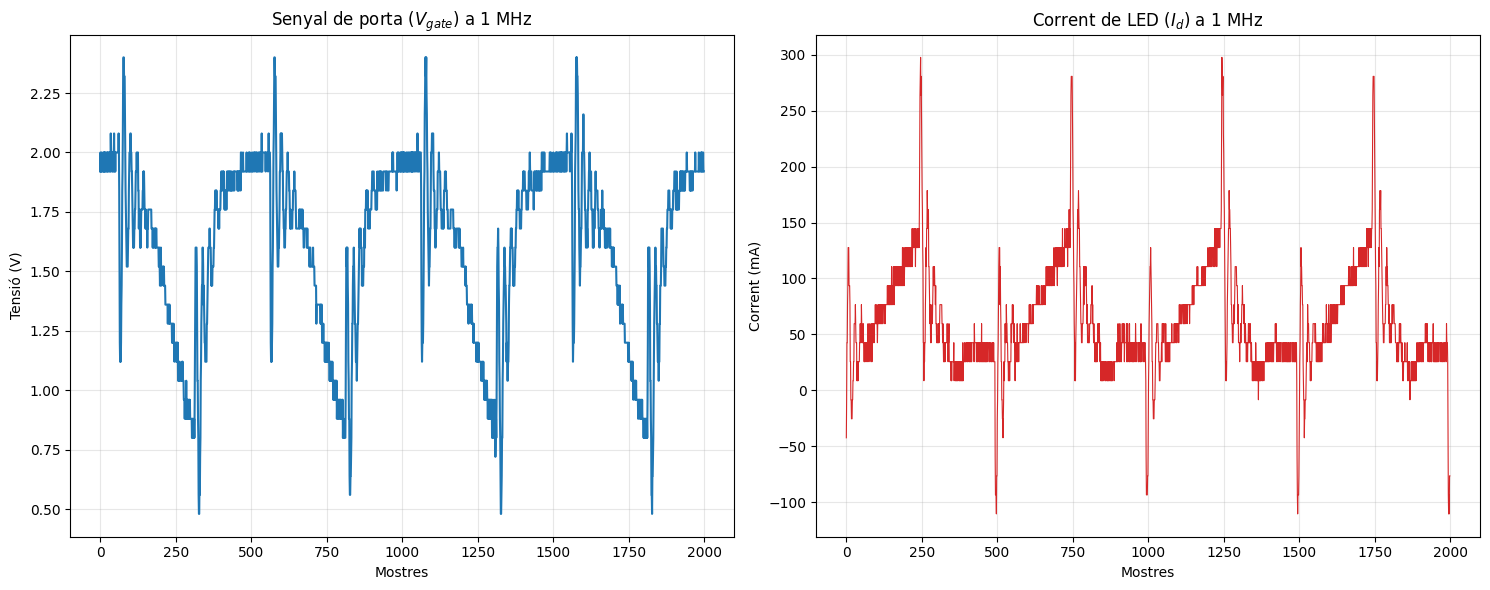

In [6]:
tx_rx_system.convertir_senyal_osciloscopi(
    senyal_csv="fitxers/1MHz_V_gate.csv",
    senyal_neta_csv="fitxers/1MHz_V_gate_neta.csv",
    channels=1
)
tx_rx_system.convertir_senyal_osciloscopi(
    senyal_csv="fitxers/1MHz_Id.csv",
    senyal_neta_csv="fitxers/1MHz_Id_neta.csv",
    channels=1
)

signal_gate = np.loadtxt("fitxers/1MHz_V_gate_neta.csv", delimiter=',')
v_mesurada = np.loadtxt("fitxers/1MHz_Id_neta.csv", delimiter=',')

signal_Id = ((5 - v_mesurada) / resistencia) * 1000
# A tenir en compte: aquí assumeixes que els "5V" no depenen de la freqüència i no és veritat
# e.g., les inducatàncies parasites (L_p) del circuit (+ la que afegeix l'oscil.) + el on-off del driver (di/dt) creen pics de corrent segons freq
# Voltage que cau a R: V(t) = I(t) * R + L_p * di(t)/dt
# La menera més precisa seria mesurar els "5V" amb l'altre canal de l'oscil.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.plot(signal_gate[:2000], color='tab:blue')
ax1.set_title("Senyal de porta ($V_{gate}$) a 1 MHz")
ax1.set_xlabel("Mostres")
ax1.set_ylabel("Tensió (V)")
ax1.grid(True, alpha=0.3)
ax2.plot(signal_Id[:2000], color='tab:red', linewidth=0.8)
ax2.set_title("Corrent de LED ($I_d$) a 1 MHz")
ax2.set_xlabel("Mostres")
ax2.set_ylabel("Corrent (mA)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Interpretació del resultat

## EXPERIMENT 1: Resposta en freq. i ample de banda EMISOR

En aquest apartat es realitza un sweep de freqüència, és a dir, una variació progressiva de la freqüència del senyal d’entrada des de 1 kHz fins a 7.5 MHz, mantenint la resta de paràmetres constants (amplitud i forma del senyal).

#### Objectiu:

L’objectiu principal és analitzar el comportament dinàmic del sistema davant diferents velocitats de commutació, i determinar fins a quina freqüència el sistema és capaç de respondre correctament.

Processing A (Target: 50.000 kHz)...
Guardat: fitxers/BW_TX_v1/a_neta_rx.csv i fitxers/BW_TX_v1/a_neta_tx.csv
  Amplitude: 122.5866 mA  |  Found at: 50.000 kHz
Processing B (Target: 100.000 kHz)...
Guardat: fitxers/BW_TX_v1/b_neta_rx.csv i fitxers/BW_TX_v1/b_neta_tx.csv
  Amplitude: 126.6069 mA  |  Found at: 100.000 kHz
Processing C (Target: 200.000 kHz)...
Guardat: fitxers/BW_TX_v1/c_neta_rx.csv i fitxers/BW_TX_v1/c_neta_tx.csv
  Amplitude: 124.4075 mA  |  Found at: 200.000 kHz
Processing D (Target: 300.000 kHz)...
Guardat: fitxers/BW_TX_v1/d_neta_rx.csv i fitxers/BW_TX_v1/d_neta_tx.csv
  Amplitude: 1.8633 mA  |  Found at: 281.250 kHz
Processing E (Target: 400.000 kHz)...
Guardat: fitxers/BW_TX_v1/e_neta_rx.csv i fitxers/BW_TX_v1/e_neta_tx.csv
  Amplitude: 89.5324 mA  |  Found at: 406.250 kHz
Processing F (Target: 450.000 kHz)...
Guardat: fitxers/BW_TX_v1/f_neta_rx.csv i fitxers/BW_TX_v1/f_neta_tx.csv
  Amplitude: 71.1295 mA  |  Found at: 437.500 kHz
Processing G (Target: 500.000 kHz)

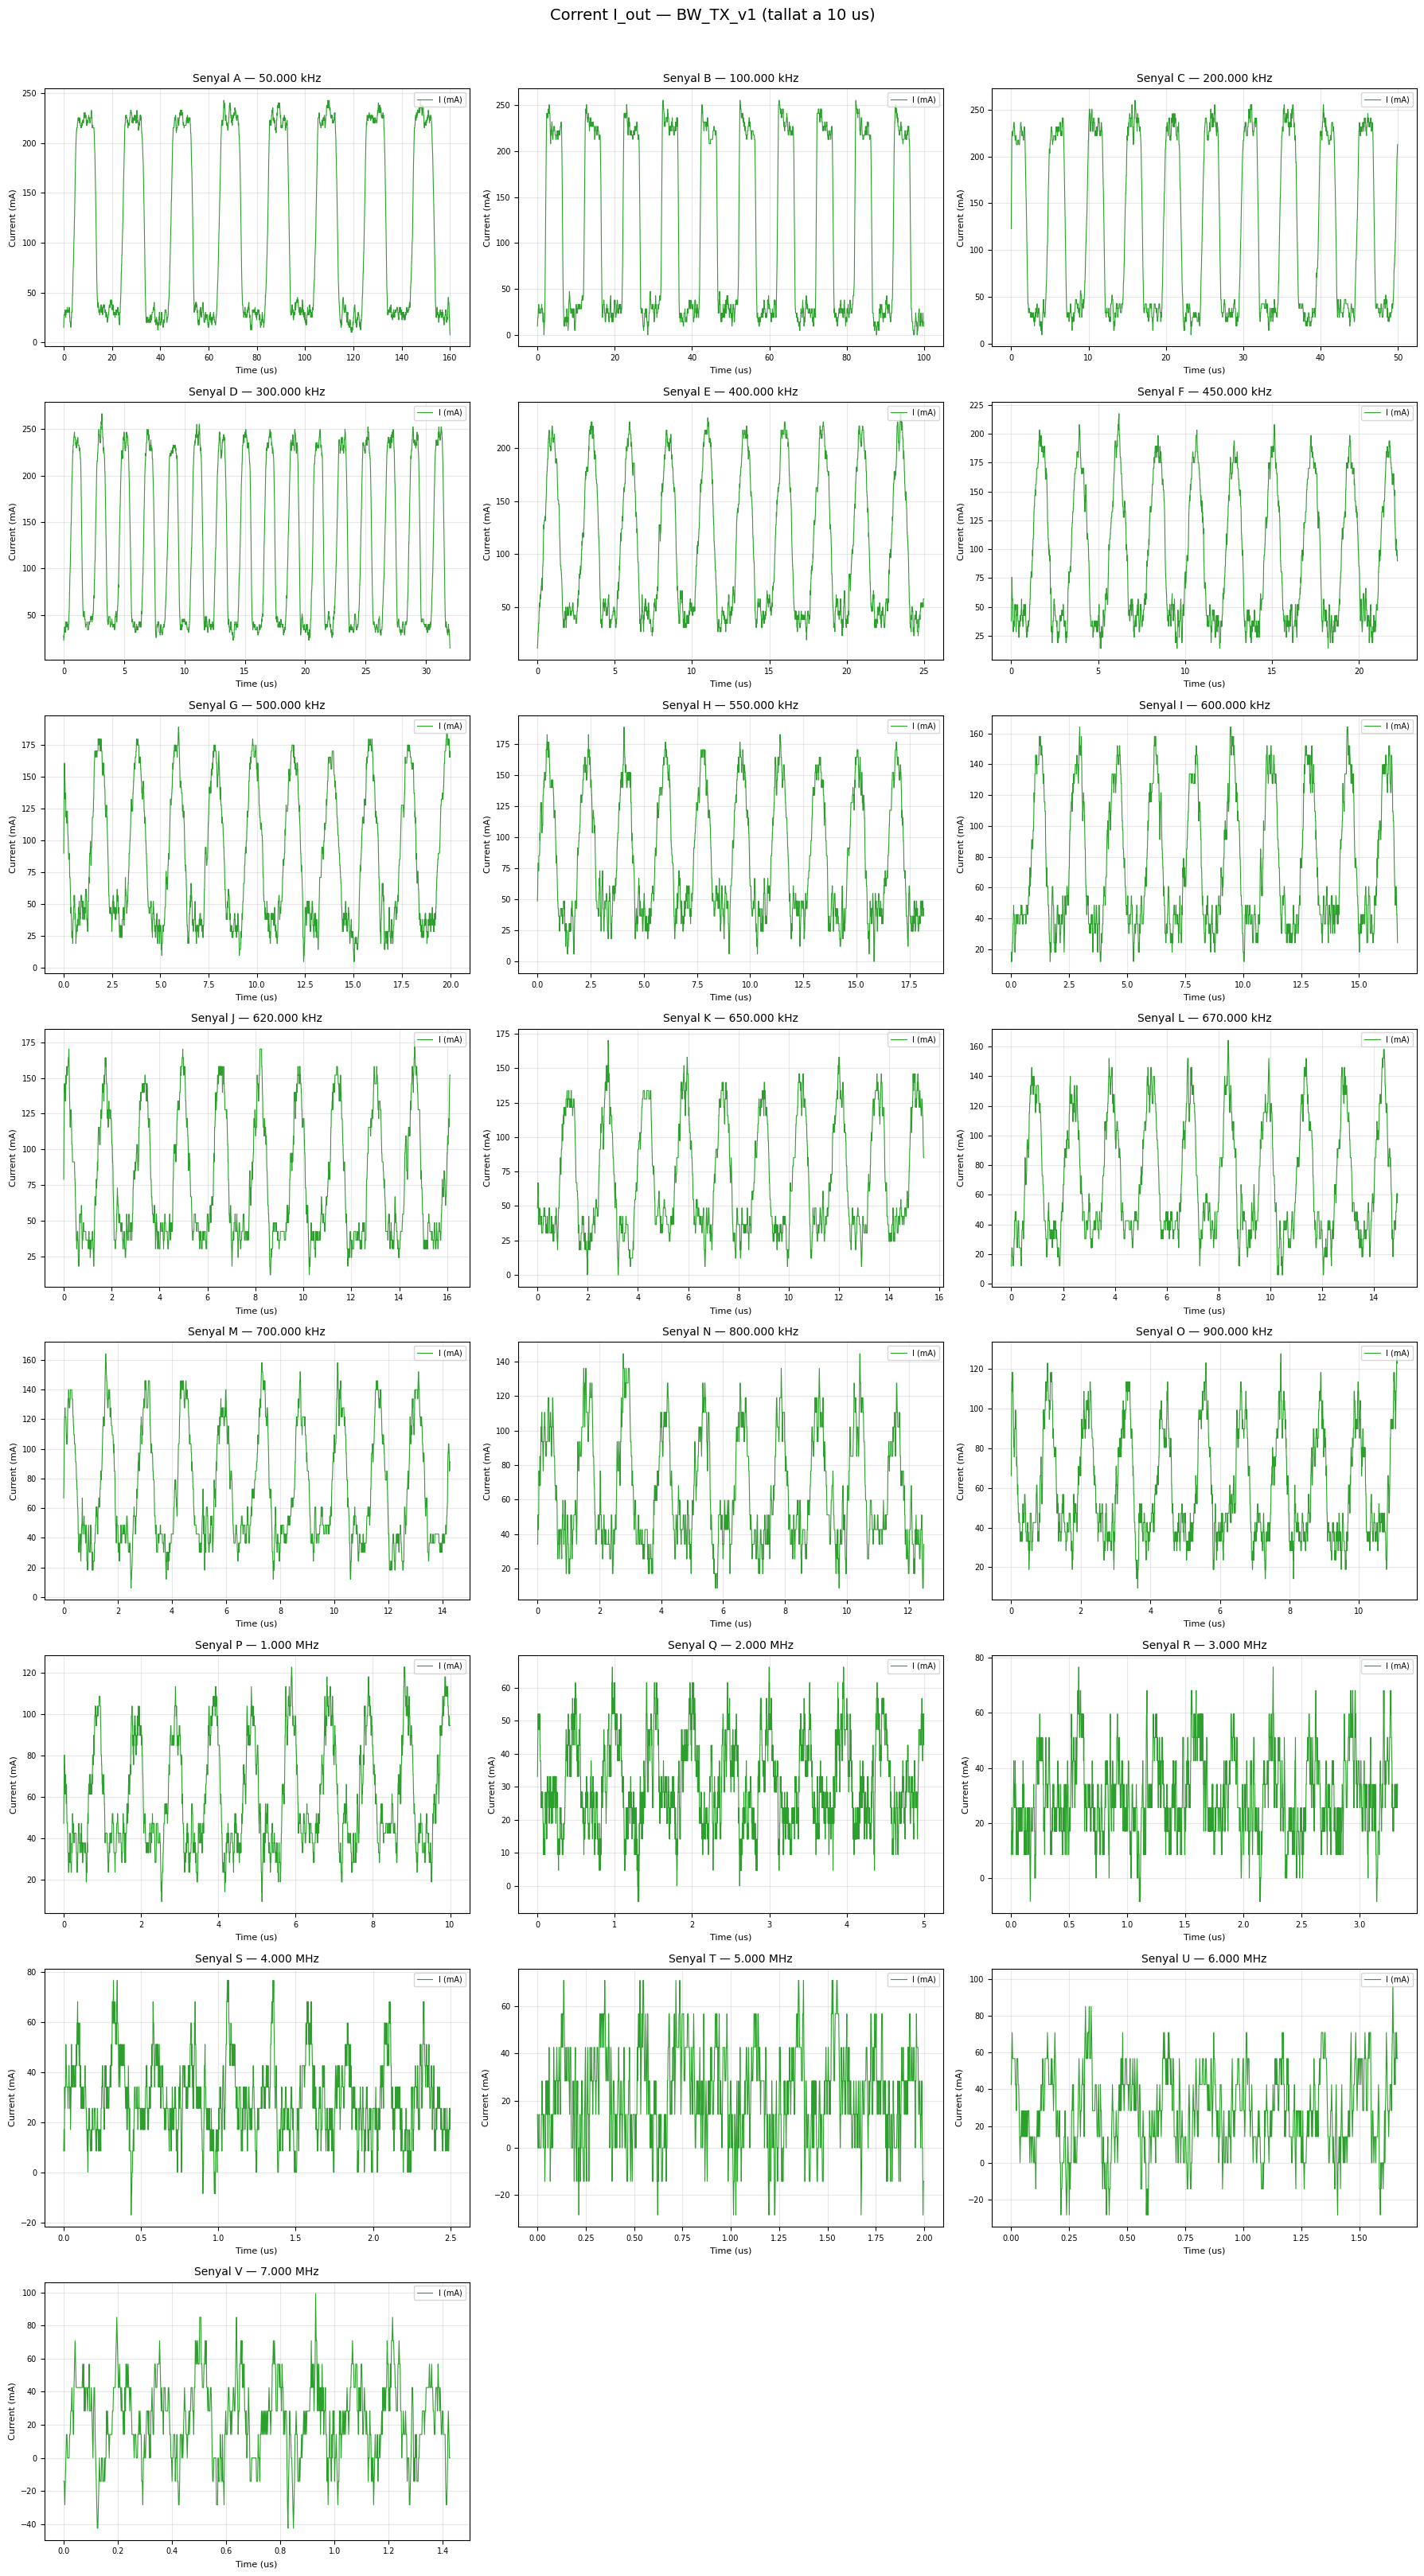

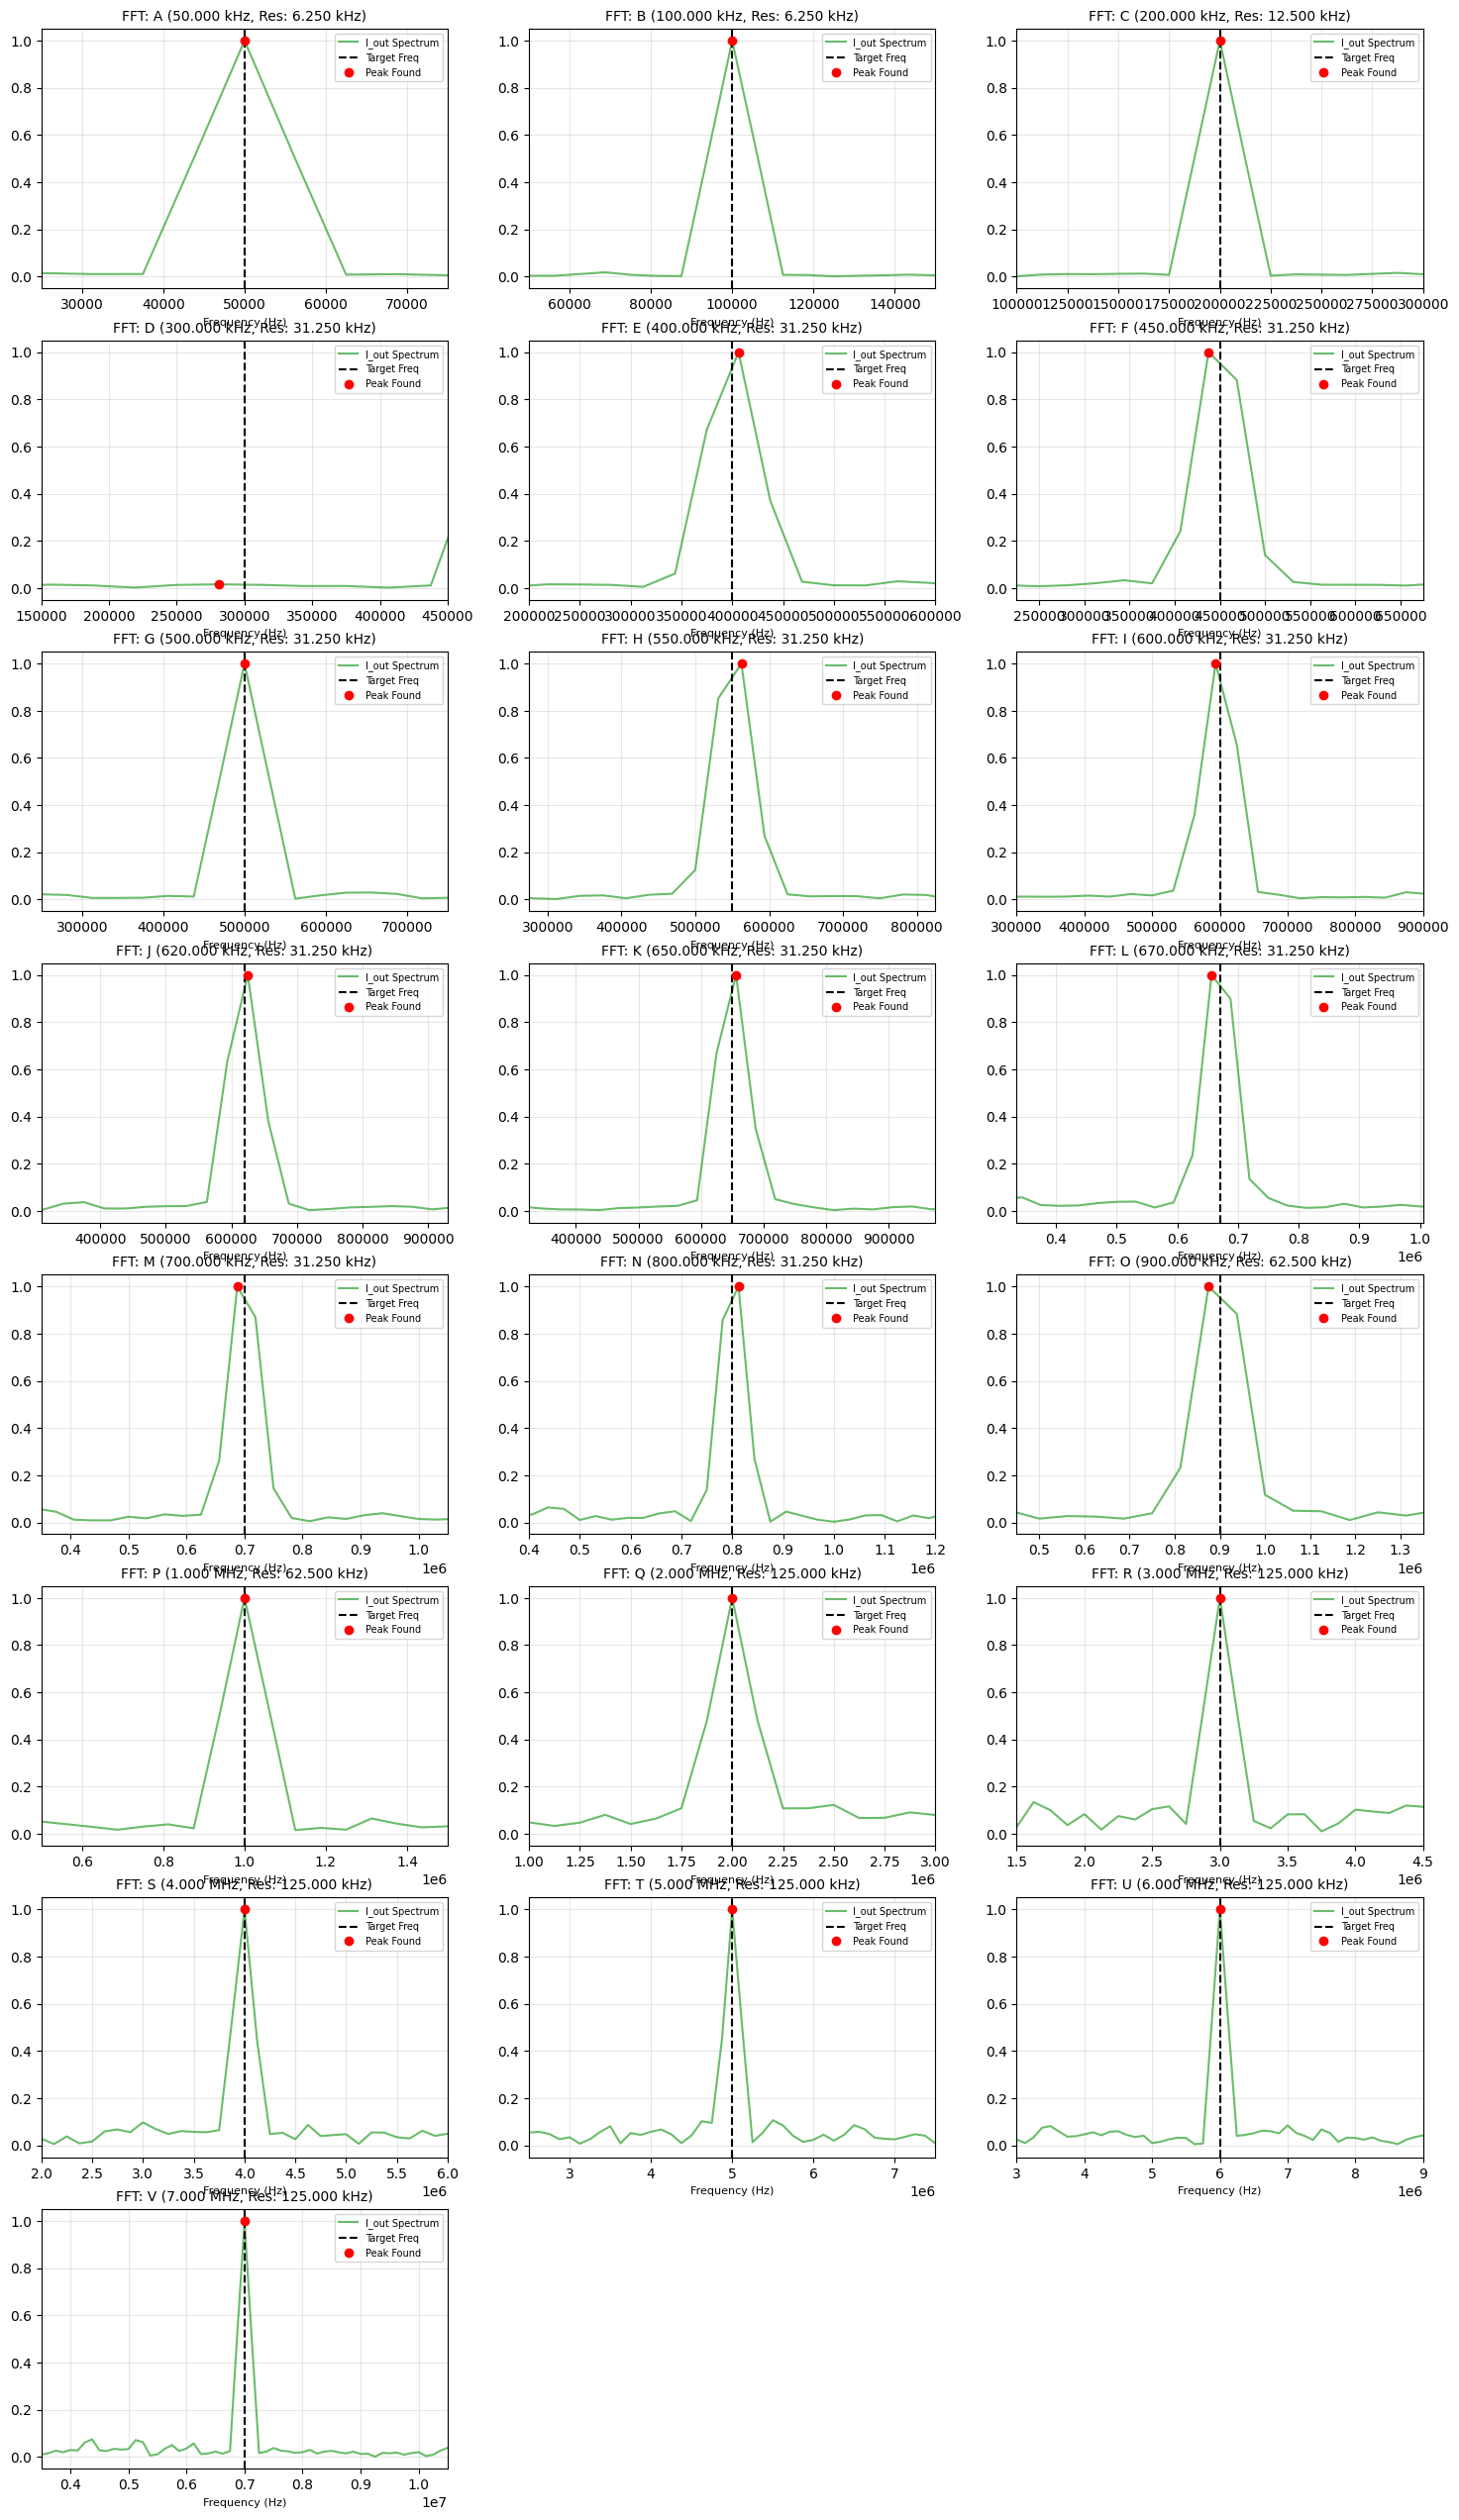

Saved: fitxers/BW_TX_v1/fft_debug.png

  LED DRIVER BANDWIDTH — BW_TX_v1
  Peak Freq:               100.000 kHz
  Lower -3 dB Cutoff (f_L): N/A
  Upper -3 dB Cutoff (f_H): 206.430 kHz
  Low-pass Bandwidth:       206.430 kHz



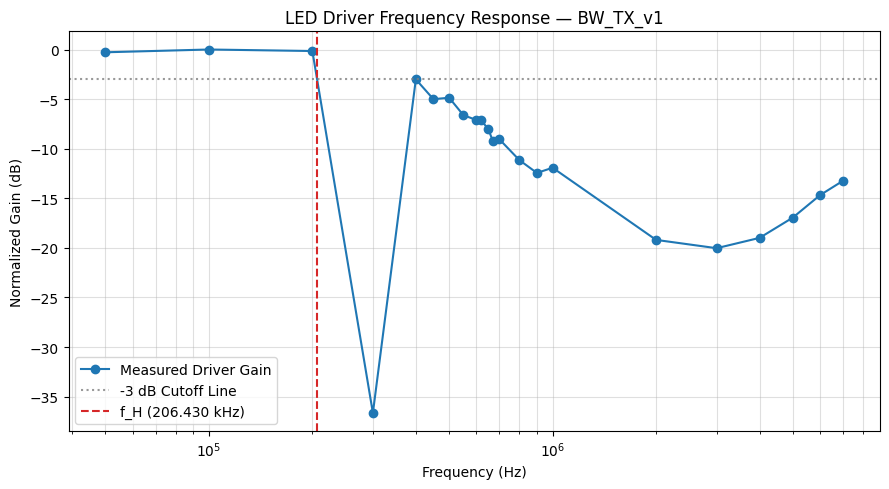

Saved: fitxers/BW_TX_v1/system_frequency_response.png


In [2]:
tx_rx_system.experiment1_BODE(
    freqs=[
        50000, 100000, 200000, 300000, 400000, 450000, 500000, 550000,
        600000, 620000, 650000, 670000, 700000, 800000, 900000, 1000000,
        2000000, 3000000, 4000000, 5000000, 6000000, 7000000,
    ],
    sampling_rates=[
        25e6, 25e6, 50e6, 125e6, 125e6, 125e6, 125e6, 125e6,
        125e6, 125e6, 125e6, 125e6, 125e6, 125e6, 250e6, 250e6,
        500e6, 500e6, 500e6, 500e6, 500e6, 500e6,
    ],
    senyals=["a","b","c","d","e","f","g","h","i","j","k","l","m","n","o","p","q","r","s","t","u","v"],
    folder="BW_TX_v1",
    resistencia=4.7,
)

TODO:  Argumentar: 

Hi havia un problema de sampling point-> Exporràven només 4k i fa que no coincideixin bins. Tornem a utilitzar però ignornat senyal a 300kHx ja que no es pot detectar bé le pic i fa que grafica no funcioni

Processing A (Target: 50.000 kHz)...
Guardat: fitxers/BW_TX_v1/a_neta_rx.csv i fitxers/BW_TX_v1/a_neta_tx.csv
  Amplitude: 122.5866 mA  |  Found at: 50.000 kHz
Processing B (Target: 100.000 kHz)...
Guardat: fitxers/BW_TX_v1/b_neta_rx.csv i fitxers/BW_TX_v1/b_neta_tx.csv
  Amplitude: 126.6069 mA  |  Found at: 100.000 kHz
Processing C (Target: 200.000 kHz)...
Guardat: fitxers/BW_TX_v1/c_neta_rx.csv i fitxers/BW_TX_v1/c_neta_tx.csv
  Amplitude: 124.4075 mA  |  Found at: 200.000 kHz
Processing E (Target: 400.000 kHz)...
Guardat: fitxers/BW_TX_v1/e_neta_rx.csv i fitxers/BW_TX_v1/e_neta_tx.csv
  Amplitude: 89.5324 mA  |  Found at: 406.250 kHz
Processing F (Target: 450.000 kHz)...
Guardat: fitxers/BW_TX_v1/f_neta_rx.csv i fitxers/BW_TX_v1/f_neta_tx.csv
  Amplitude: 71.1295 mA  |  Found at: 437.500 kHz
Processing G (Target: 500.000 kHz)...
Guardat: fitxers/BW_TX_v1/g_neta_rx.csv i fitxers/BW_TX_v1/g_neta_tx.csv
  Amplitude: 72.3420 mA  |  Found at: 500.000 kHz
Processing H (Target: 550.000 kHz

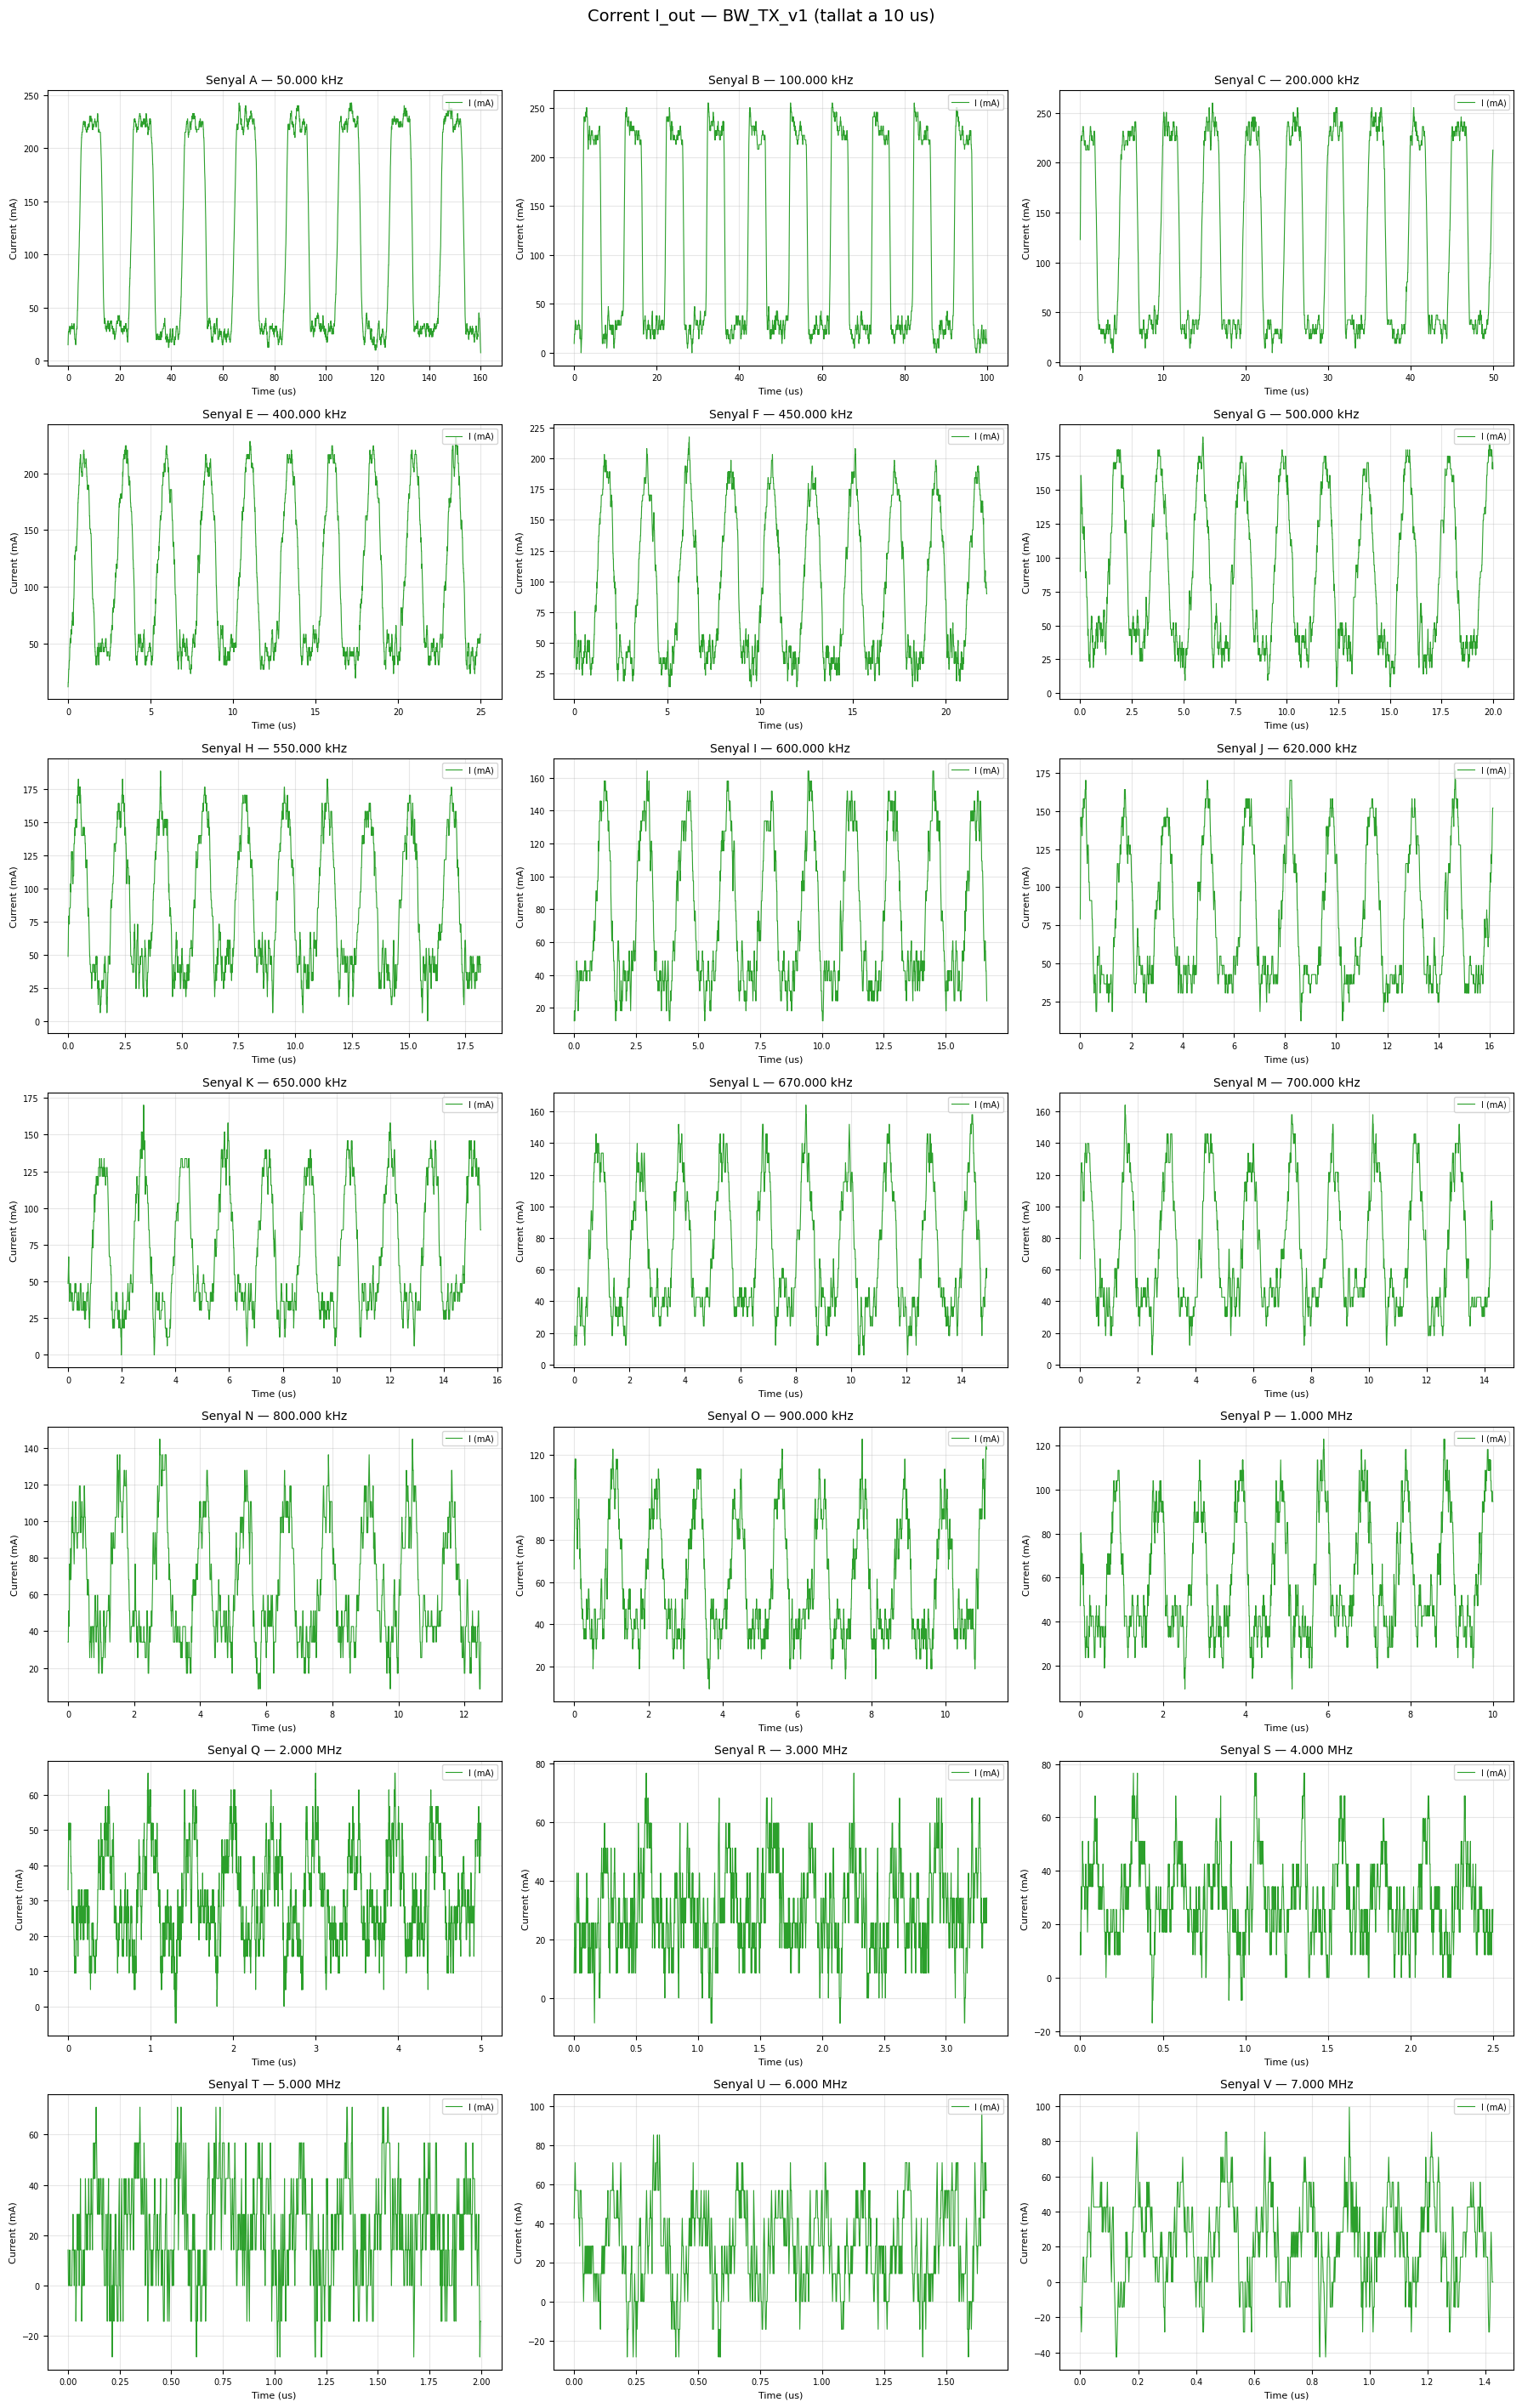

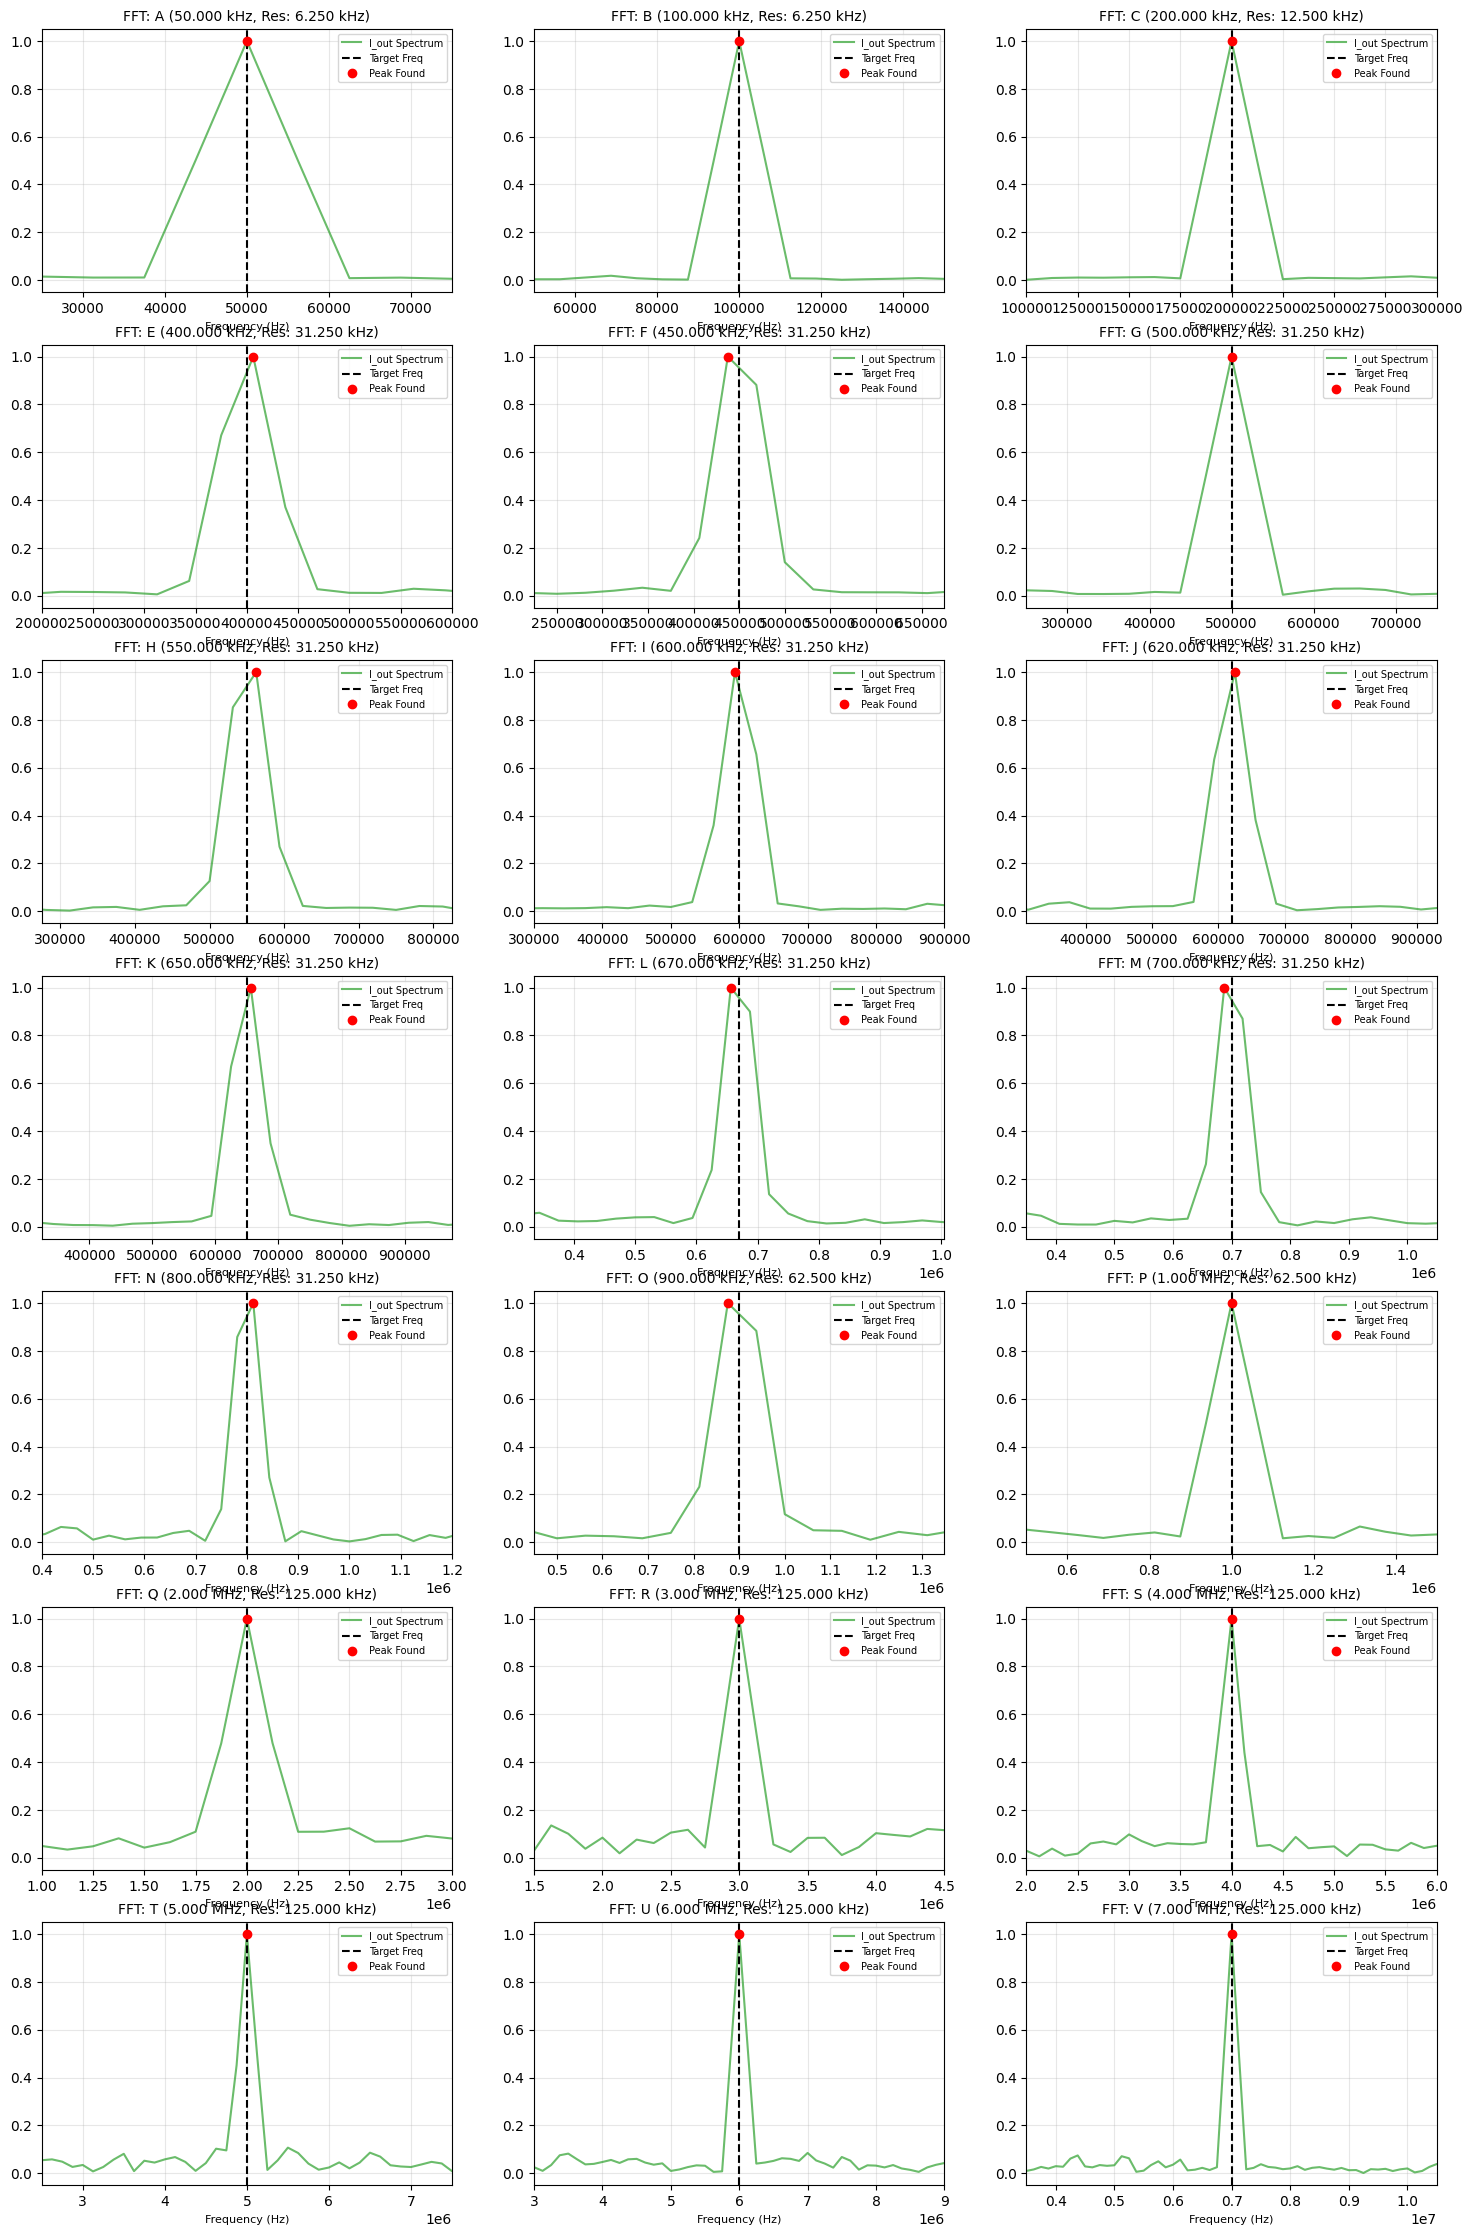

Saved: fitxers/BW_TX_v1/fft_debug.png

  LED DRIVER BANDWIDTH — BW_TX_v1
  Peak Freq:               100.000 kHz
  Lower -3 dB Cutoff (f_L): N/A
  Upper -3 dB Cutoff (f_H): 399.075 kHz
  Low-pass Bandwidth:       399.075 kHz



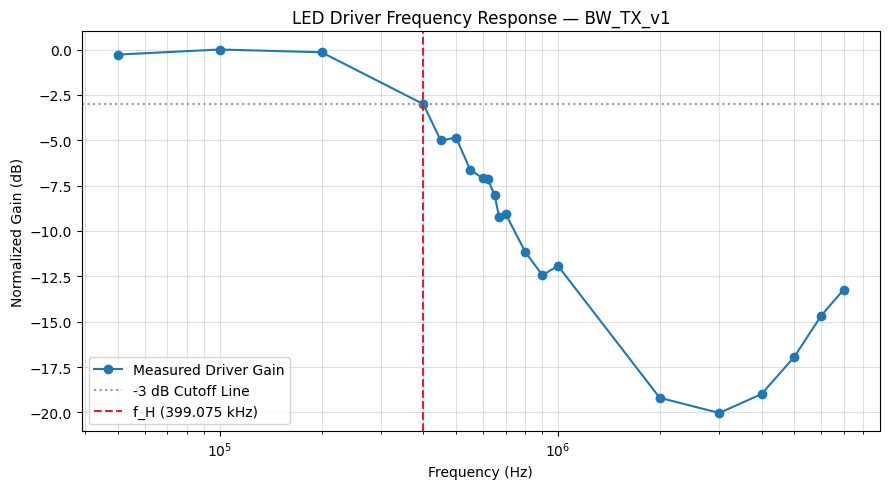

Saved: fitxers/BW_TX_v1/system_frequency_response.png


In [3]:
tx_rx_system.experiment1_BODE(
    freqs=[
        50000, 100000, 200000, 400000, 450000, 500000, 550000,
        600000, 620000, 650000, 670000, 700000, 800000, 900000, 1000000,
        2000000, 3000000, 4000000, 5000000, 6000000, 7000000,
    ],
    sampling_rates=[
        25e6, 25e6, 50e6, 125e6, 125e6, 125e6, 125e6,
        125e6, 125e6, 125e6, 125e6, 125e6, 125e6, 250e6, 250e6,
        500e6, 500e6, 500e6, 500e6, 500e6, 500e6,
    ],
    senyals=["a","b","c","e","f","g","h","i","j","k","l","m","n","o","p","q","r","s","t","u","v"],
    folder="BW_TX_v1",
    resistencia=4.7,
)

Ara repetim l'experiment però emprant sondes en comptes de cables normals amb cocodrils. I importem els .csv amb 400k punts en comptes de 4k punts (més resolució).

Processing A (Target: 1.000 Hz)...
Guardat: fitxers/BW_TX_v2/a_neta_rx.csv i fitxers/BW_TX_v2/a_neta_tx.csv
  Amplitude: 128.8779 mA  |  Found at: 1.000 Hz
Processing B (Target: 2.000 Hz)...
Guardat: fitxers/BW_TX_v2/b_neta_rx.csv i fitxers/BW_TX_v2/b_neta_tx.csv
  Amplitude: 128.8802 mA  |  Found at: 2.000 Hz
Processing C (Target: 5.000 Hz)...
Guardat: fitxers/BW_TX_v2/c_neta_rx.csv i fitxers/BW_TX_v2/c_neta_tx.csv
  Amplitude: 127.7587 mA  |  Found at: 5.000 Hz
Processing D (Target: 10.000 Hz)...
Guardat: fitxers/BW_TX_v2/d_neta_rx.csv i fitxers/BW_TX_v2/d_neta_tx.csv
  Amplitude: 125.2794 mA  |  Found at: 10.000 Hz
Processing E (Target: 20.000 Hz)...
Guardat: fitxers/BW_TX_v2/e_neta_rx.csv i fitxers/BW_TX_v2/e_neta_tx.csv
  Amplitude: 123.3945 mA  |  Found at: 20.000 Hz
Processing F (Target: 50.000 Hz)...
Guardat: fitxers/BW_TX_v2/f_neta_rx.csv i fitxers/BW_TX_v2/f_neta_tx.csv
  Amplitude: 113.4356 mA  |  Found at: 50.000 Hz
Processing G (Target: 100.000 Hz)...
Guardat: fitxers/BW_T

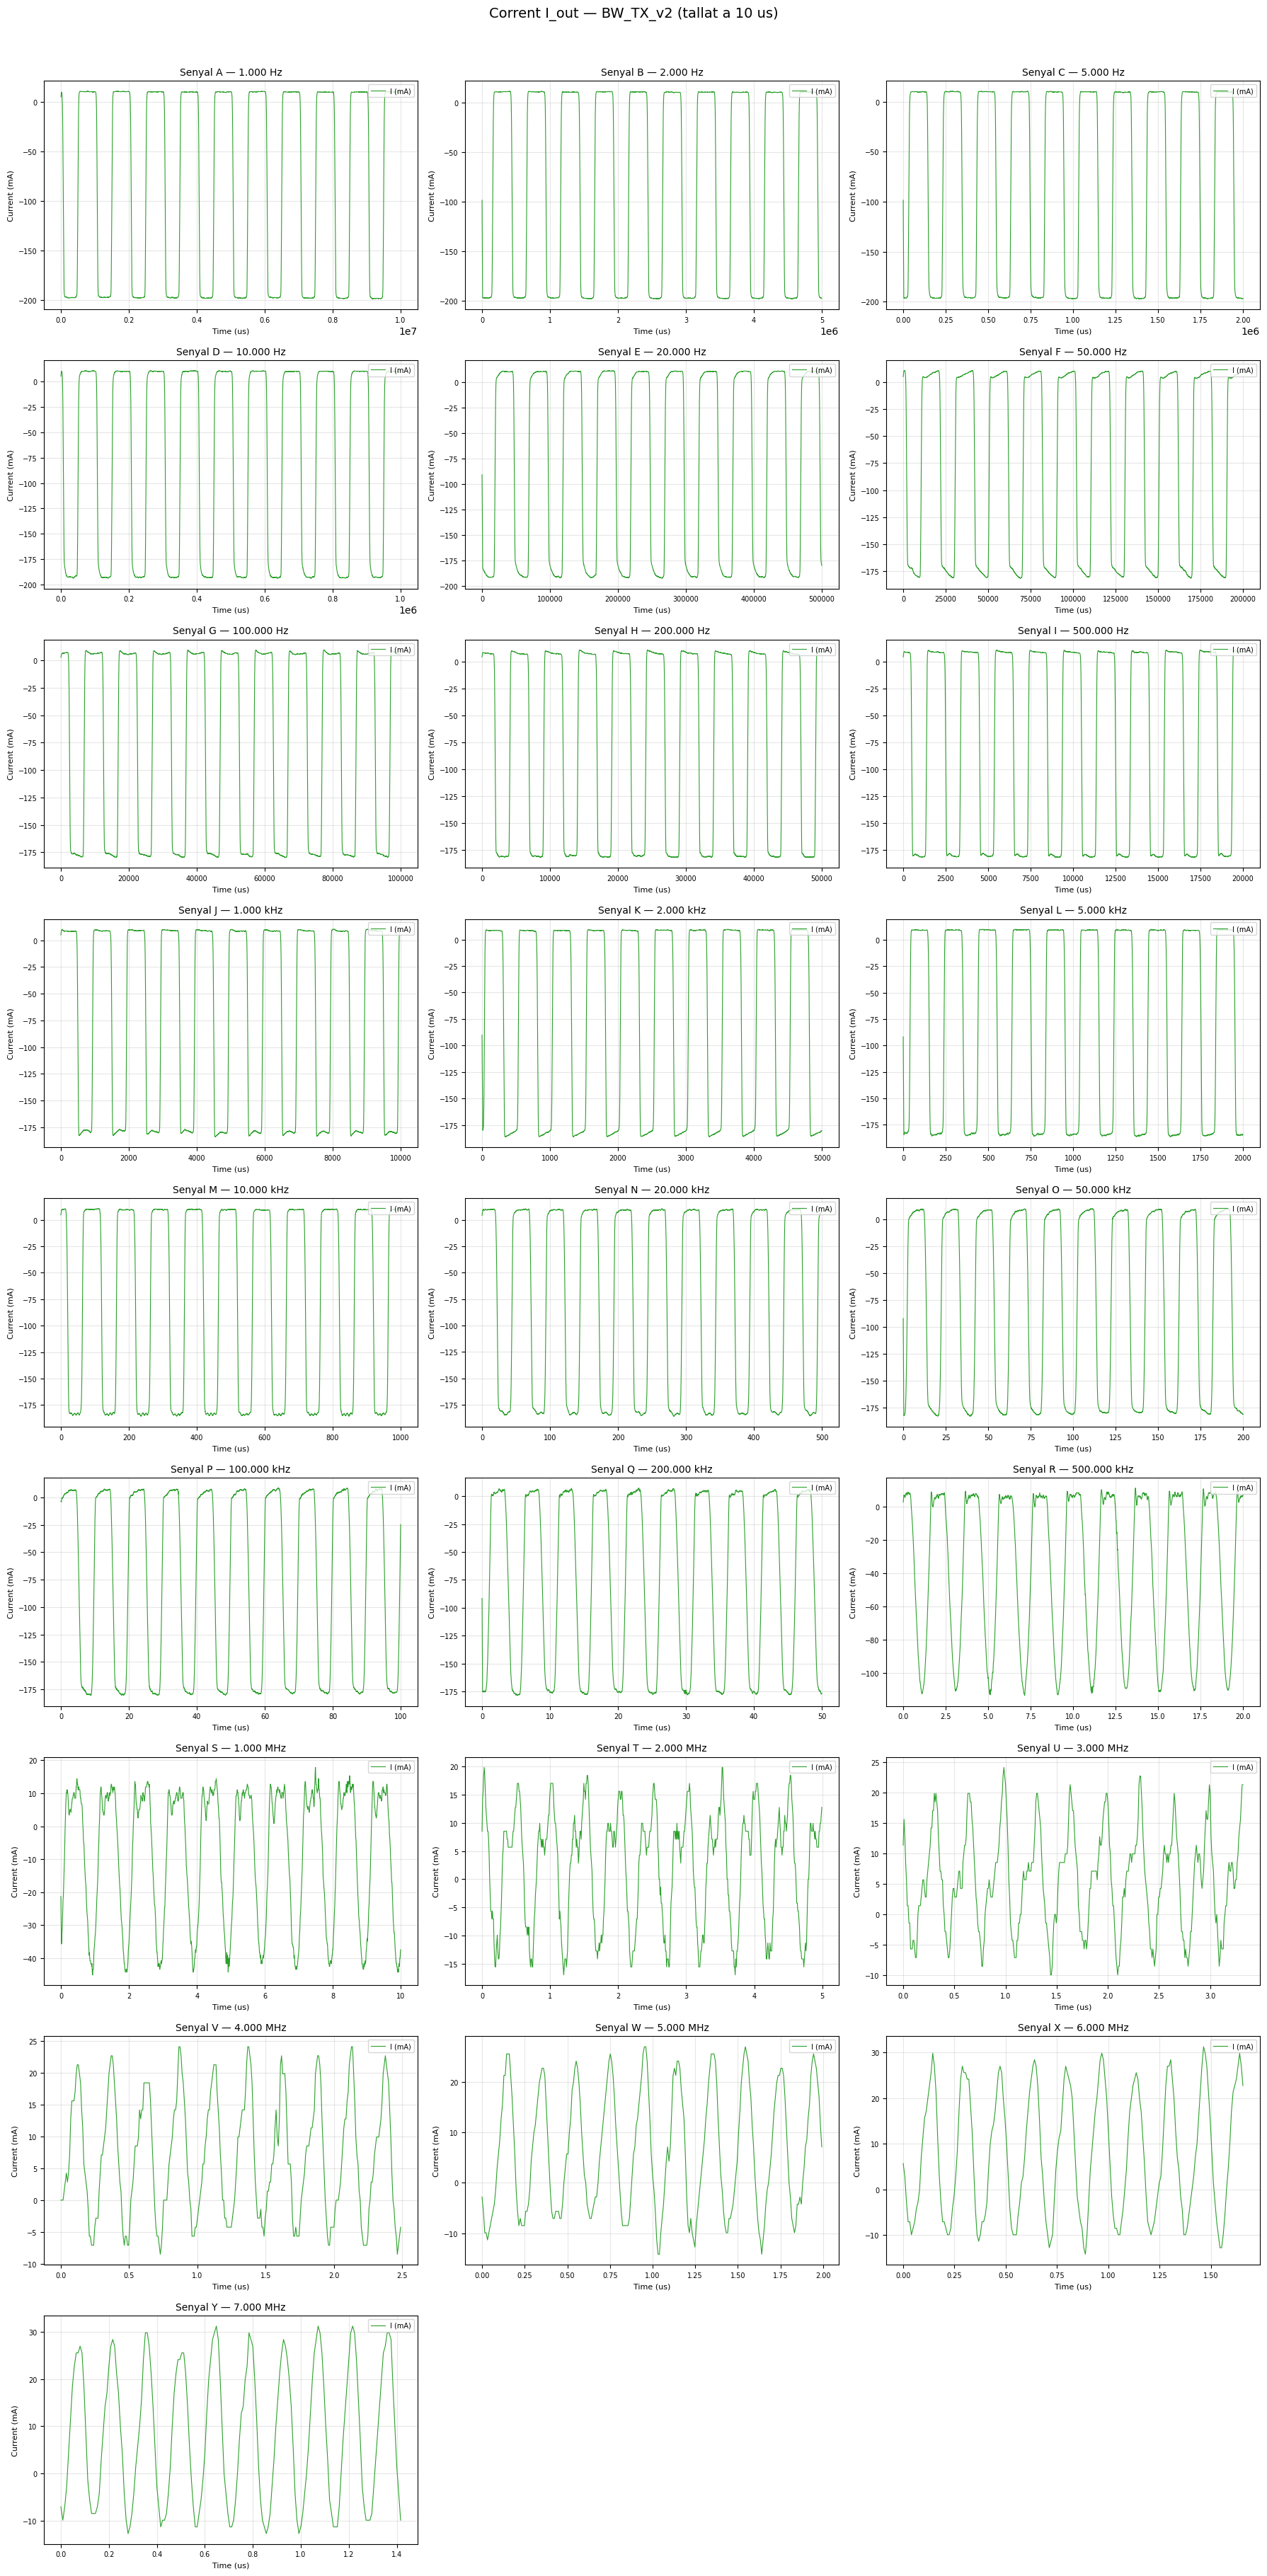

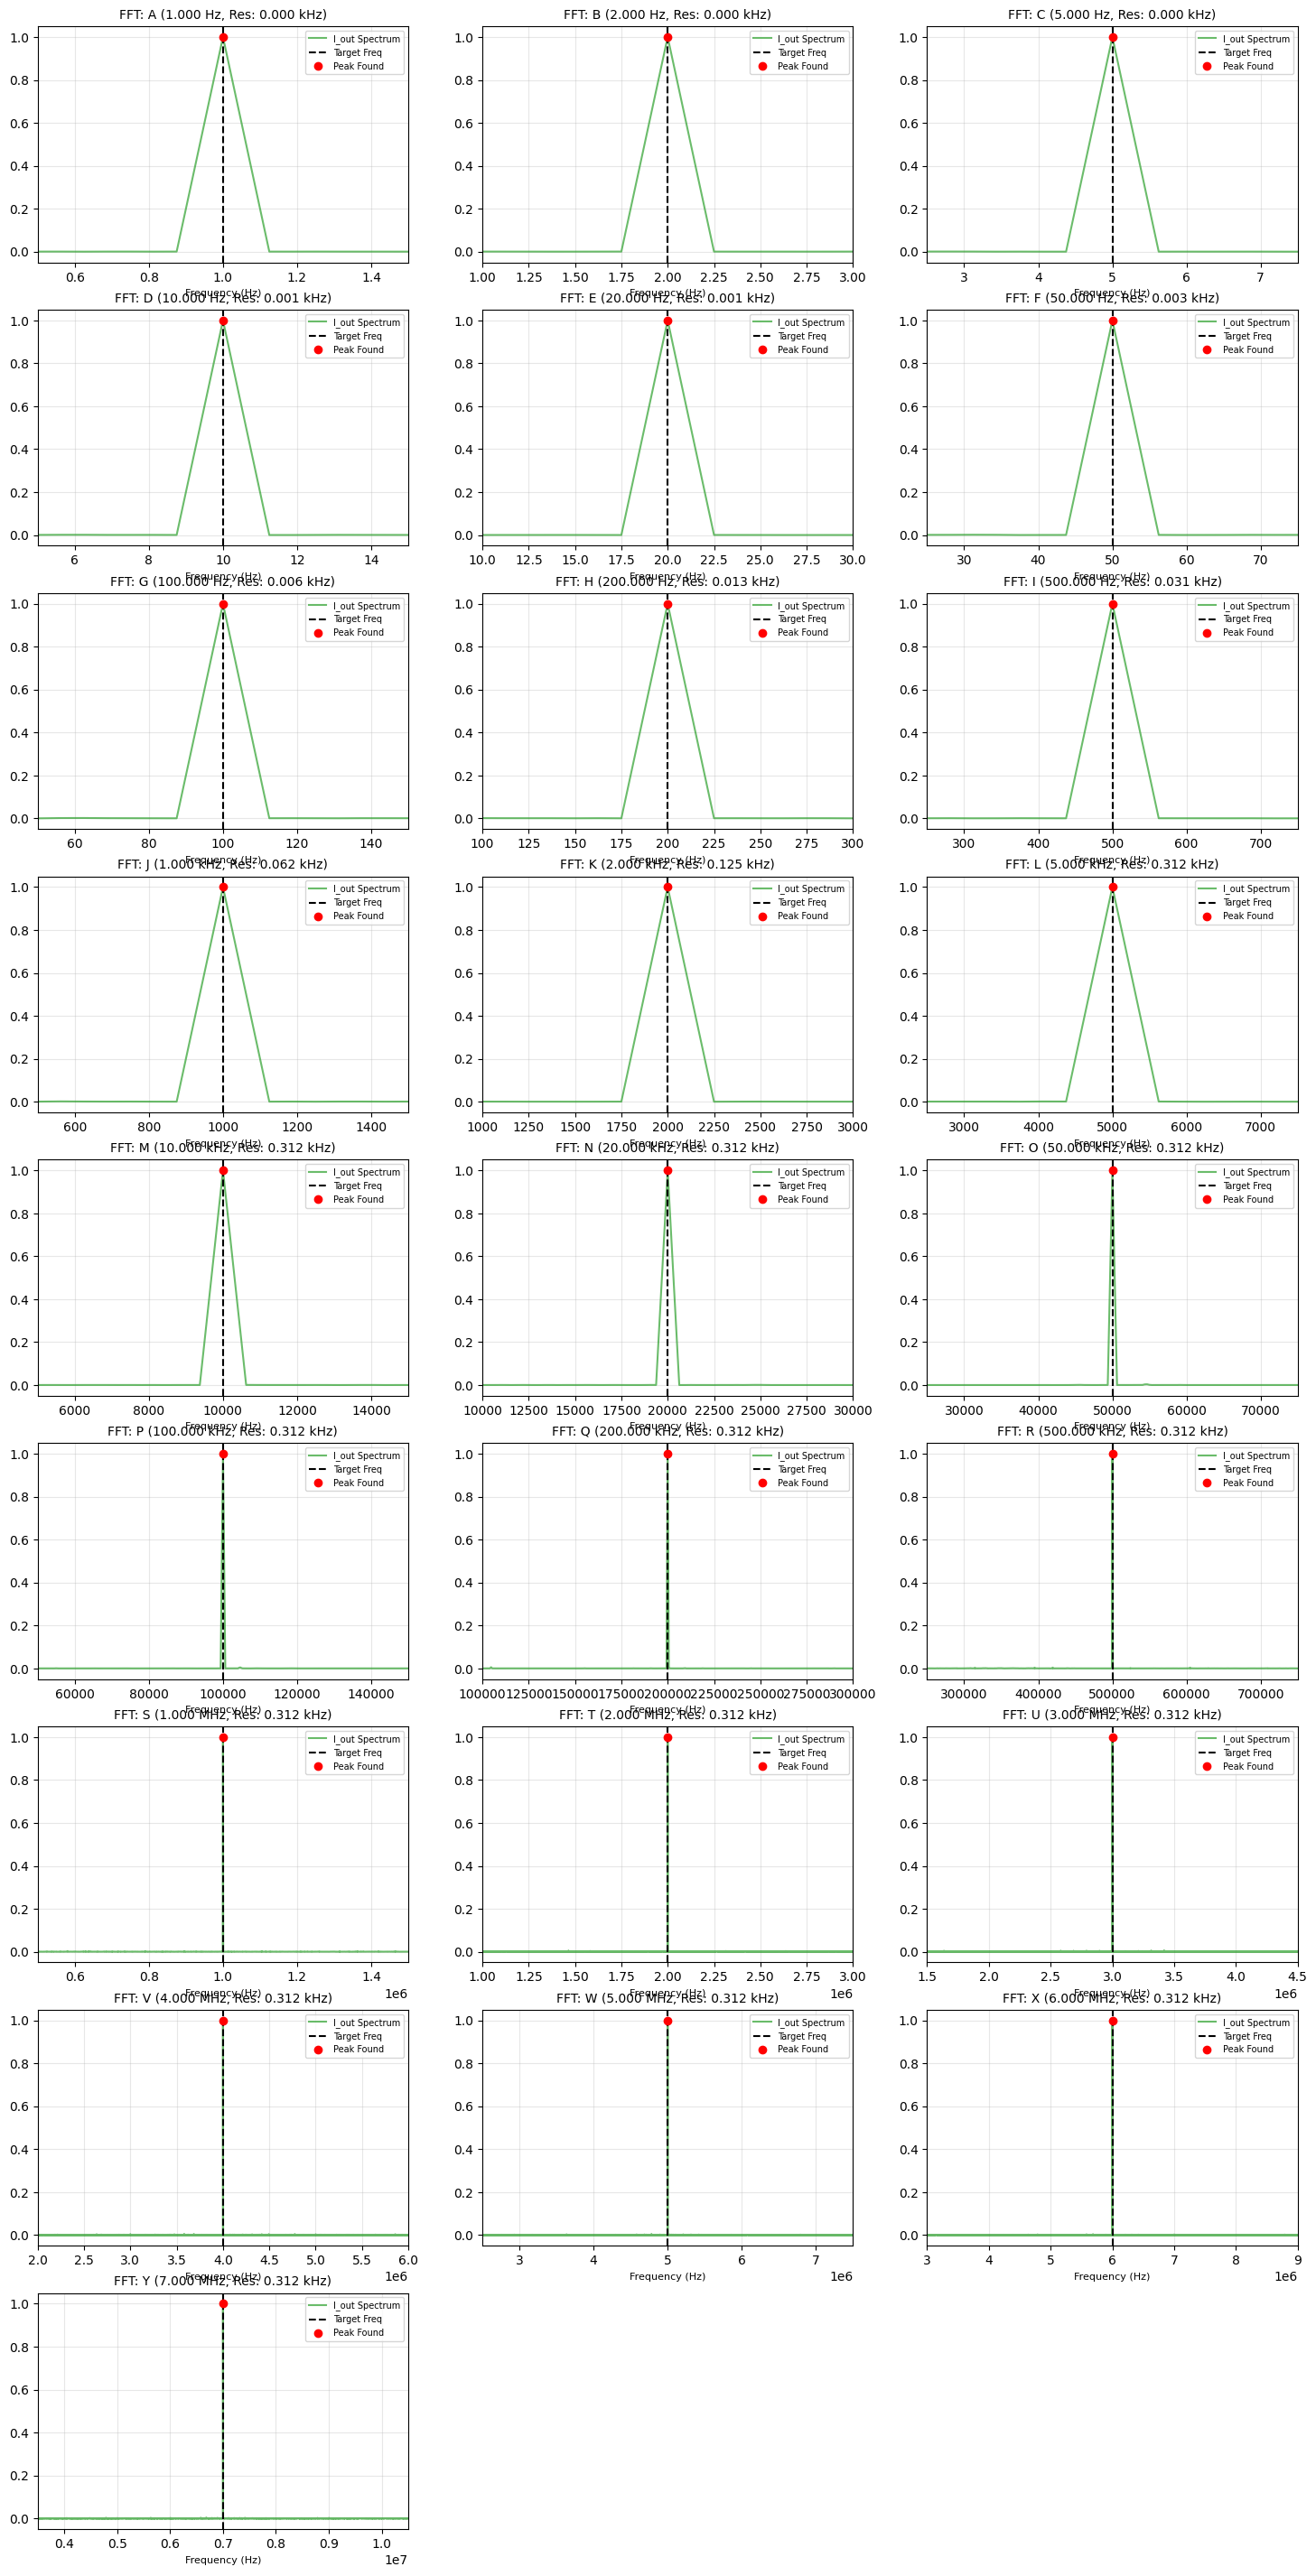

Saved: fitxers/BW_TX_v2/fft_debug.png

  LED DRIVER BANDWIDTH — BW_TX_v2
  Peak Freq:               2.000 Hz
  Lower -3 dB Cutoff (f_L): N/A
  Upper -3 dB Cutoff (f_H): 261.110 kHz
  Low-pass Bandwidth:       261.110 kHz



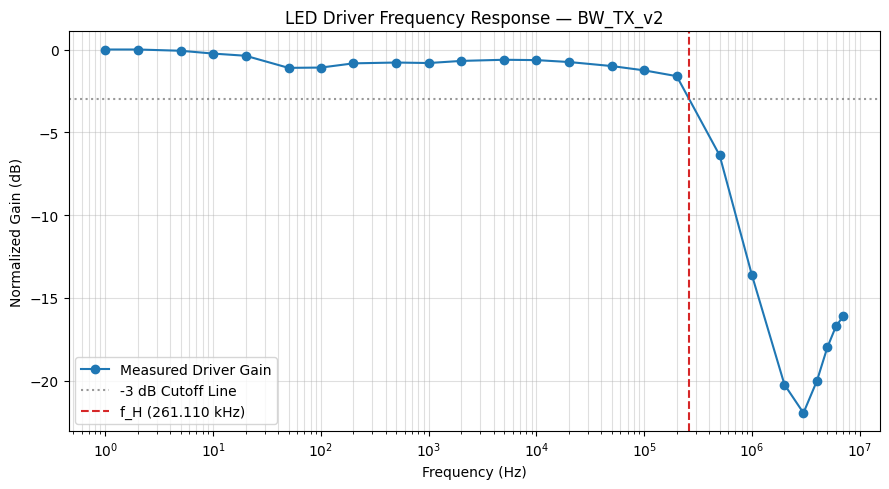

Saved: fitxers/BW_TX_v2/system_frequency_response.png


In [4]:
tx_rx_system.experiment1_BODE(
    freqs=[
        1, 2, 5, 10, 20, 50, 100, 200, 500,
        1e3, 2e3, 5e3, 10e3, 20e3, 50e3, 100e3, 200e3, 500e3,
        1e6, 2e6, 3e6, 4e6, 5e6, 6e6, 7e6,
    ],
    sampling_rates=[
        25e3, 50e3, 125e3, 250e3, 500e3, 1.25e6, 2.5e6, 5e6, 12.5e6,
        25e6, 50e6, 125e6, 125e6, 125e6, 125e6, 125e6, 125e6, 125e6,
        125e6, 125e6, 125e6, 125e6, 125e6, 125e6, 125e6,
    ],
    senyals=["a","b","c","d","e","f","g","h","i","j","k","l","m","n","o","p","q","r","s","t","u","v","w","x","y"],
    folder="BW_TX_v2",
    resistencia=4.7,
)

Anem també a mesurar a 300k i 400k per tenir més precisió a l'hora de calcular bw:

Processing A (Target: 1.000 Hz)...
Guardat: fitxers/BW_TX_v2/a_neta_rx.csv i fitxers/BW_TX_v2/a_neta_tx.csv
  Amplitude: 128.8779 mA  |  Found at: 1.000 Hz
Processing B (Target: 2.000 Hz)...
Guardat: fitxers/BW_TX_v2/b_neta_rx.csv i fitxers/BW_TX_v2/b_neta_tx.csv
  Amplitude: 128.8802 mA  |  Found at: 2.000 Hz
Processing C (Target: 5.000 Hz)...
Guardat: fitxers/BW_TX_v2/c_neta_rx.csv i fitxers/BW_TX_v2/c_neta_tx.csv
  Amplitude: 127.7587 mA  |  Found at: 5.000 Hz
Processing D (Target: 10.000 Hz)...
Guardat: fitxers/BW_TX_v2/d_neta_rx.csv i fitxers/BW_TX_v2/d_neta_tx.csv
  Amplitude: 125.2794 mA  |  Found at: 10.000 Hz
Processing E (Target: 20.000 Hz)...
Guardat: fitxers/BW_TX_v2/e_neta_rx.csv i fitxers/BW_TX_v2/e_neta_tx.csv
  Amplitude: 123.3945 mA  |  Found at: 20.000 Hz
Processing F (Target: 50.000 Hz)...
Guardat: fitxers/BW_TX_v2/f_neta_rx.csv i fitxers/BW_TX_v2/f_neta_tx.csv
  Amplitude: 113.4356 mA  |  Found at: 50.000 Hz
Processing G (Target: 100.000 Hz)...
Guardat: fitxers/BW_T

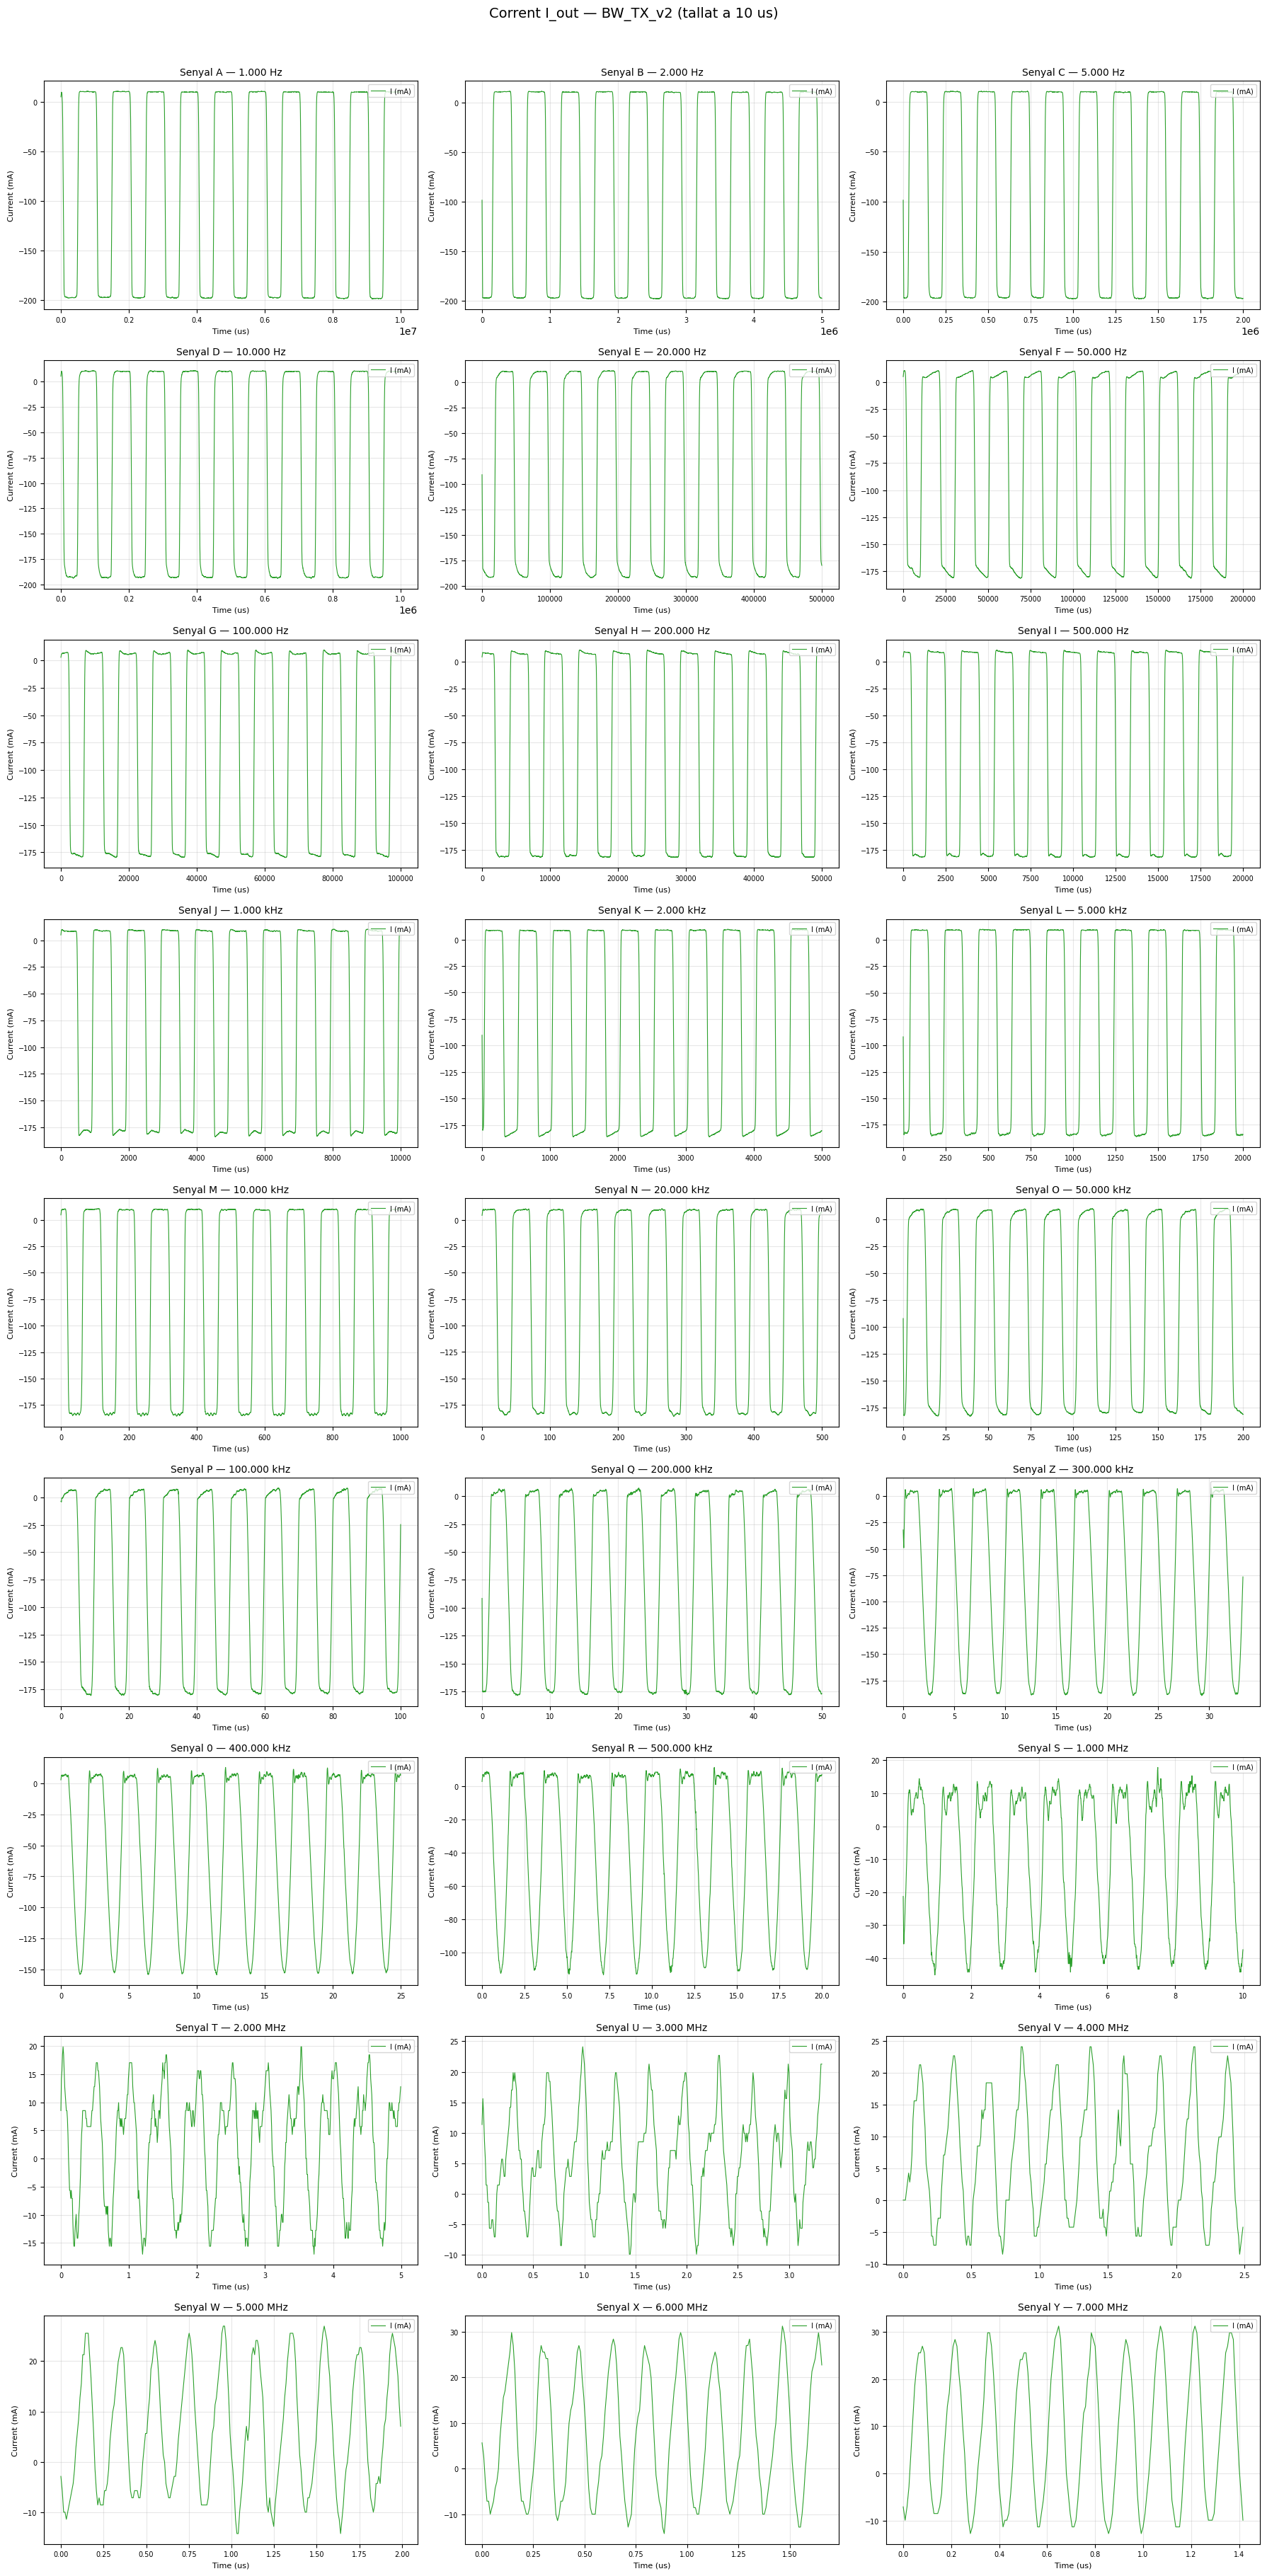

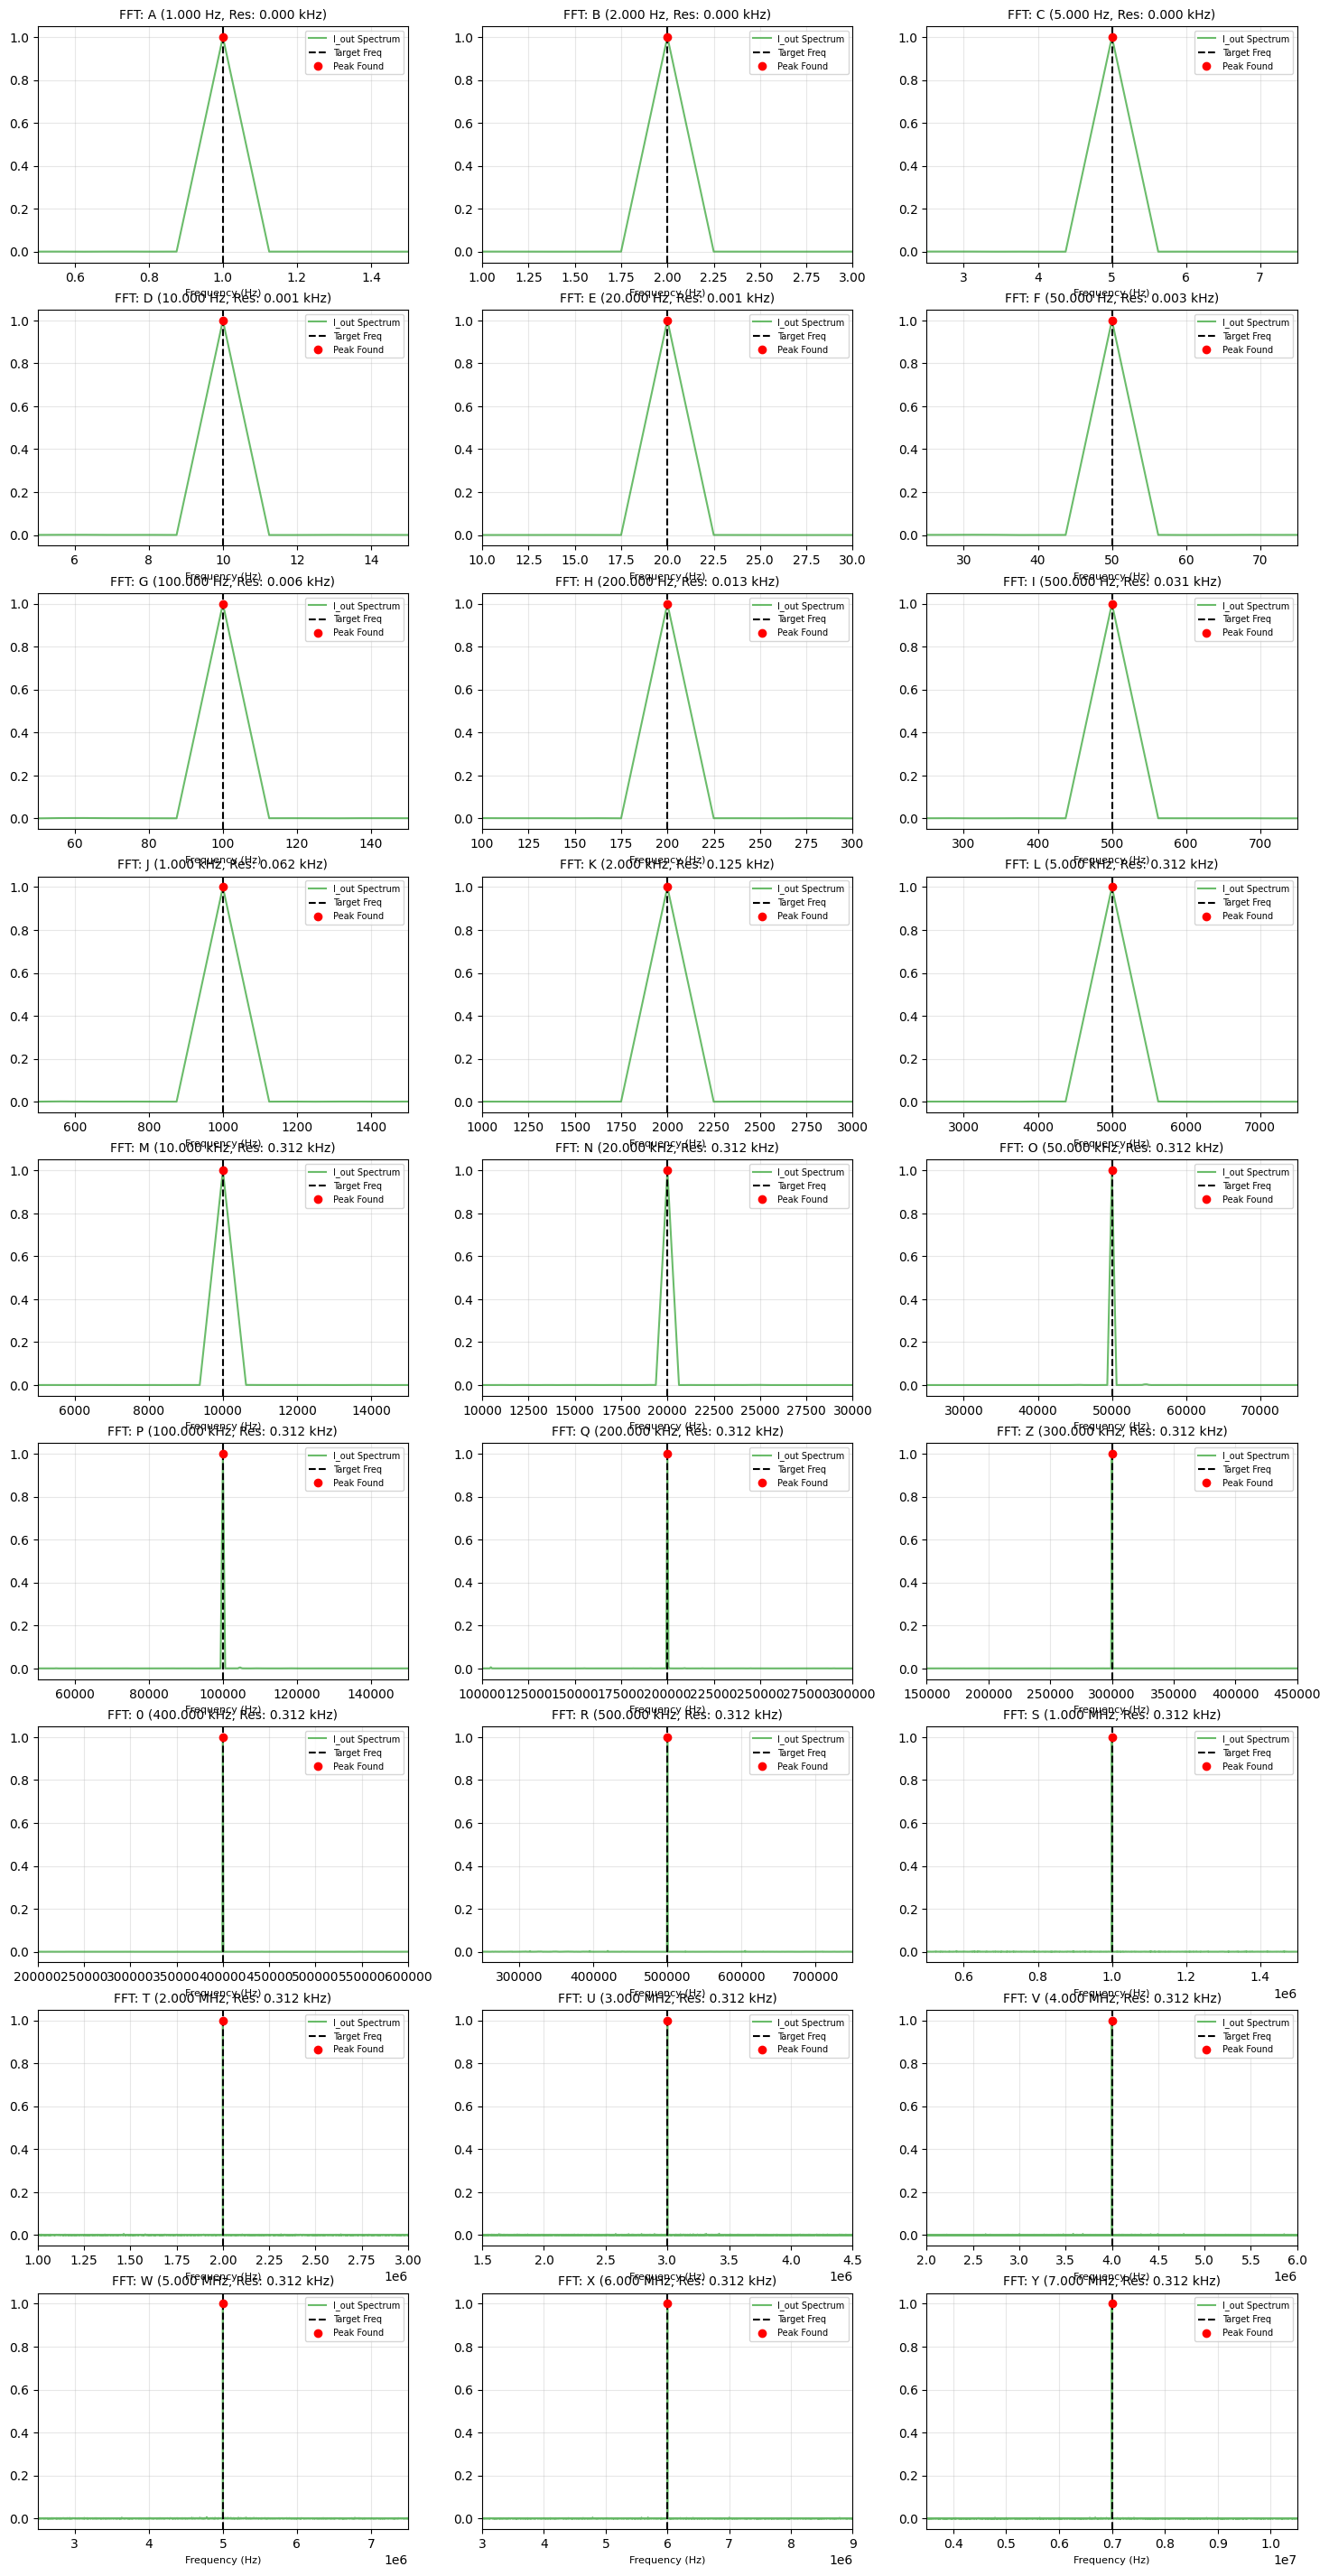

Saved: fitxers/BW_TX_v2/fft_debug.png

  LED DRIVER BANDWIDTH — BW_TX_v2
  Peak Freq:               2.000 Hz
  Lower -3 dB Cutoff (f_L): N/A
  Upper -3 dB Cutoff (f_H): 363.001 kHz
  Low-pass Bandwidth:       363.001 kHz



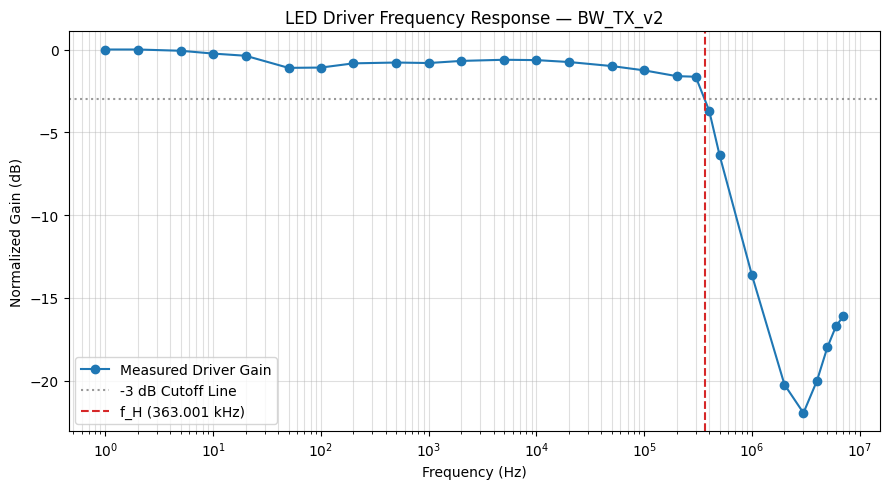

Saved: fitxers/BW_TX_v2/system_frequency_response.png


In [10]:
tx_rx_system.experiment1_BODE(
    freqs=[
        1, 2, 5, 10, 20, 50, 100, 200, 500,
        1e3, 2e3, 5e3, 10e3, 20e3, 50e3, 100e3, 200e3, 300e3, 400e3, 500e3,
        1e6, 2e6, 3e6, 4e6, 5e6, 6e6, 7e6,
    ],
    sampling_rates=[
        25e3, 50e3, 125e3, 250e3, 500e3, 1.25e6, 2.5e6, 5e6, 12.5e6,
        25e6, 50e6, 125e6, 125e6, 125e6, 125e6, 125e6, 125e6, 125e6, 125e6, 125e6,
        125e6, 125e6, 125e6, 125e6, 125e6, 125e6, 125e6,
    ],
    senyals=["a","b","c","d","e","f","g","h","i","j","k","l","m","n","o","p","q","z","0","r","s","t","u","v","w","x","y"],
    folder="BW_TX_v2",
    resistencia=4.7,
)

## EXPERIMENT 2: Ample de banda del receptor amb senyal del LED driver

Per tal de fer aquest experiment, s'ha emprat una senyal quadrada de 3.3 V amb una 
freqüència d'1 kHz. S'ha mesurat el temps de pujada (*rise time*) de la sortida del 
OPT101 amb l'oscil·loscopi, obtenint:

$$V_{max} = 2.64 \ \text{V}, \qquad V_{min} = 0 \ \text{V}$$

Els llindars del 10\% i 90\% són:

$$V_{10\%} = 0.1 \times 2.64 = 0.264 \ \text{V}$$
$$V_{90\%} = 0.9 \times 2.64 = 2.376 \ \text{V}$$

El temps de pujada mesurat entre aquests dos llindars és:

$$t_r \approx 20 \ \mu\text{s}$$

L'ample de banda del receptor s'obté a partir de la relació entre el temps de pujada 
d'un sistema de primer ordre RC i la seva freqüència de tall:

$$B = \frac{0.35}{t_r}$$

Substituint el valor mesurat:

$$B = \frac{0.35}{20 \times 10^{-6}} \approx 17.5 \ \text{kHz}$$

Aquest resultat és consistent amb el valor teòric de 14.5 kHz obtingut a partir dels 
paràmetres interns del OPT101 ($R_f = 1\ \text{M}\Omega$, $C_f = 11\ \text{pF}$):

$$B_{teoria} = \frac{1}{2\pi R_f C_f} = \frac{1}{2\pi \times 1\ \text{M}\Omega \times 11\ \text{pF}} = 14.5 \ \text{kHz}$$



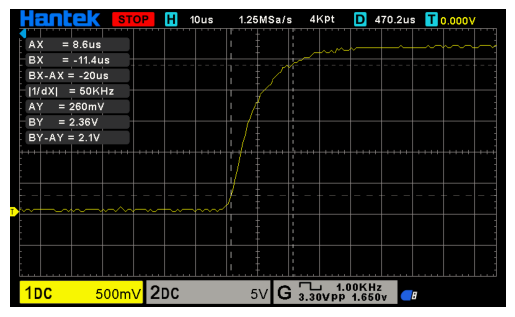

In [11]:
img = plt.imread("./fitxers/BW_receptor.bmp")
plt.imshow(img)
plt.axis("off")
plt.show()

## EXPERIMENT 3: BER vs Bitrate (Capacitat del canal)

#### Escombrar el bitrate des de valors baixos fins al límit analògic prèviament trobat. & Corba de BER vs $R_b$ i extracció del valor pràctic de $R_b^{\max}$.

In [12]:
tx_rx_system.generate_prbs_4096() 


Saved signal to fitxers/prbs.csv
Executing: python3 utils/csv2arb.py fitxers/prbs.csv
Conversion complete. ARB file saved as 'fitxers/prbs.arb'.


Un cop generada la senyal, anem a realitzar l'escombrat

  a                               BER = 0.000732  (3/4096 errors)  @983 bps
  b                               BER = 0.000732  (3/4096 errors)  @1966 bps
  c                               BER = 0.000732  (3/4096 errors)  @4915 bps
  d                               BER = 0.000732  (3/4096 errors)  @9830 bps
  e                               BER = 0.000732  (3/4096 errors)  @19661 bps
  f                               BER = 0.000732  (3/4096 errors)  @49152 bps
  g                               BER = 0.000732  (3/4096 errors)  @98304 bps
  h                               BER = 0.238037  (975/4096 errors)  @196608 bps
  i                               BER = 0.245117  (1004/4096 errors)  @299008 bps


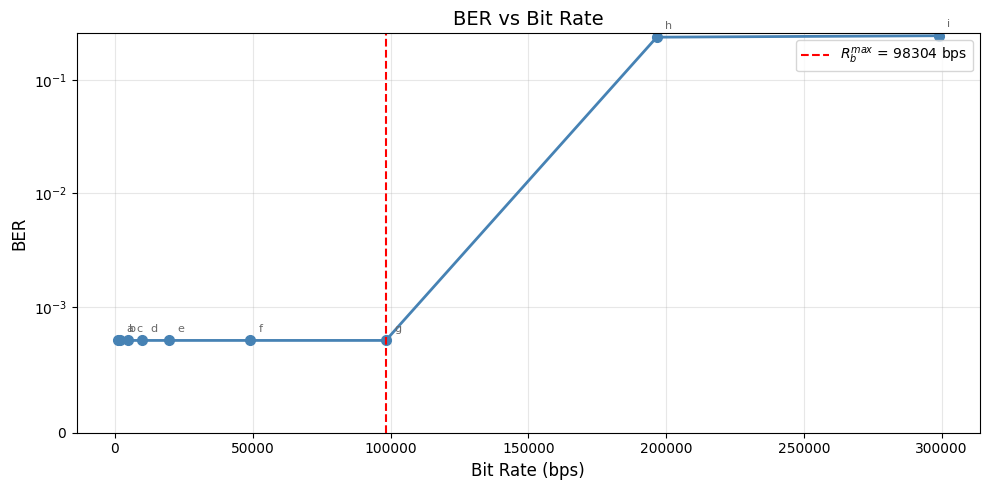

  a                               BER = 0.269795  (276/1023 errors)  @983 bps
  b                               BER = 0.269795  (276/1023 errors)  @1966 bps
  c                               BER = 0.269795  (276/1023 errors)  @4915 bps
  d                               BER = 0.269795  (276/1023 errors)  @9830 bps
  e                               BER = 0.269795  (276/1023 errors)  @19661 bps
  f                               BER = 0.269795  (276/1023 errors)  @49152 bps
  g                               BER = 0.269795  (276/1023 errors)  @98304 bps
  h                               BER = 0.510695  (191/374 errors)  @196608 bps
  i                               BER = 0.509804  (52/102 errors)  @299008 bps


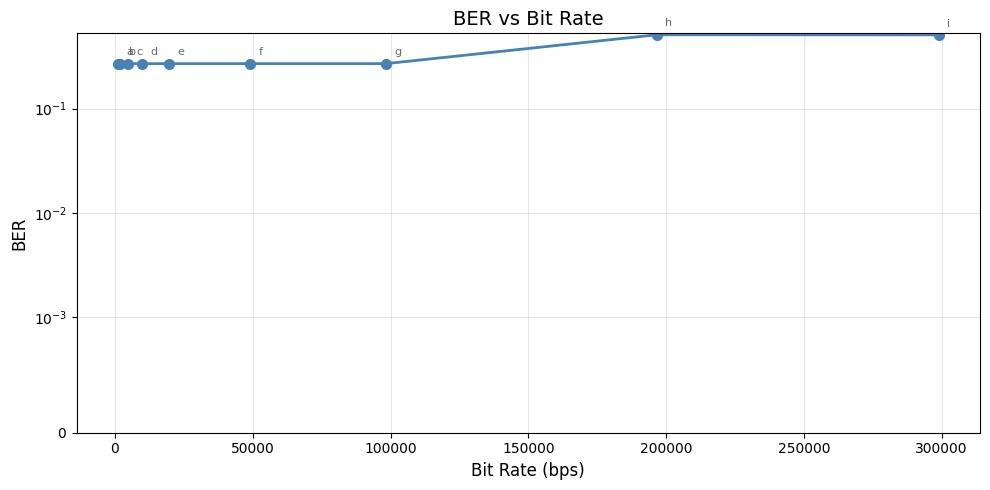

  a                               BER = 0.269795  (276/1023 errors)  @983 bps
  b                               BER = 0.269795  (276/1023 errors)  @1966 bps
  c                               BER = 0.269795  (276/1023 errors)  @4915 bps
  d                               BER = 0.269795  (276/1023 errors)  @9830 bps
  e                               BER = 0.269795  (276/1023 errors)  @19661 bps
  f                               BER = 0.269795  (276/1023 errors)  @49152 bps
  g                               BER = 0.269795  (276/1023 errors)  @98304 bps
  h                               BER = 0.510695  (191/374 errors)  @196608 bps
  i                               BER = 0.509804  (52/102 errors)  @299008 bps


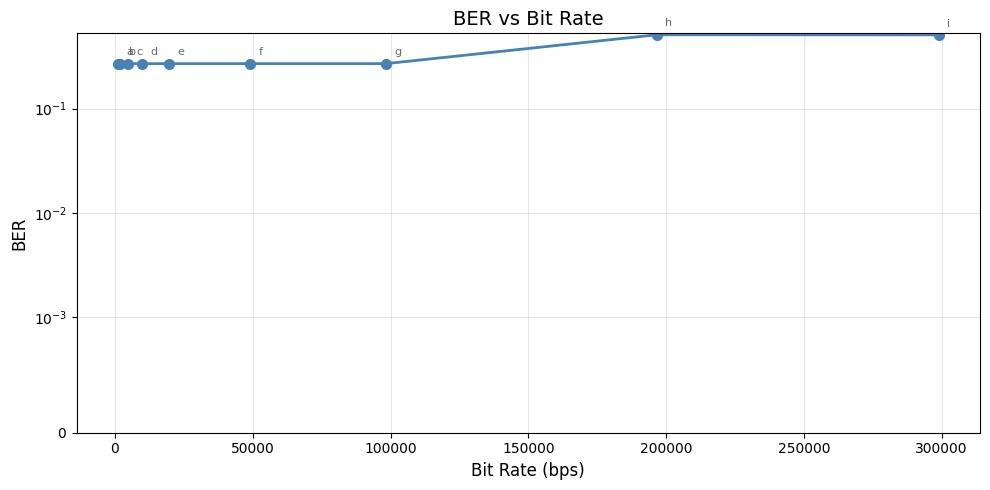

{'a': {'ber': 0.2697947214076246,
  'errors': 276,
  'total': 1023,
  'bit_rate': np.float64(983.04)},
 'b': {'ber': 0.2697947214076246,
  'errors': 276,
  'total': 1023,
  'bit_rate': np.float64(1966.08)},
 'c': {'ber': 0.2697947214076246,
  'errors': 276,
  'total': 1023,
  'bit_rate': np.float64(4915.2)},
 'd': {'ber': 0.2697947214076246,
  'errors': 276,
  'total': 1023,
  'bit_rate': np.float64(9830.4)},
 'e': {'ber': 0.2697947214076246,
  'errors': 276,
  'total': 1023,
  'bit_rate': np.float64(19660.8)},
 'f': {'ber': 0.2697947214076246,
  'errors': 276,
  'total': 1023,
  'bit_rate': np.float64(49152.0)},
 'g': {'ber': 0.2697947214076246,
  'errors': 276,
  'total': 1023,
  'bit_rate': np.float64(98304.0)},
 'h': {'ber': 0.5106951871657754,
  'errors': 191,
  'total': 374,
  'bit_rate': np.float64(196608.0)},
 'i': {'ber': 0.5098039215686274,
  'errors': 52,
  'total': 102,
  'bit_rate': np.float64(299008.0)}}

In [2]:
#OOK

N_BITS = 4096
N_SAMPLES = 400e3

freqs =np.array([0.24, 0.48, 1.2, 2.4, 4.8, 12, 24, 48, 73])
T_s = 1/freqs
time_bit= T_s / N_BITS
sampling_rates=np.array([12.5e3, 12.5e3, 25e3, 50e3, 125e3, 250e3, 500e3, 1.25e6, 2.5e6])
time_per_sample =1/sampling_rates
bits_per_sample = time_bit / time_per_sample
signals= ["a","b","c","d","e","f","g","h","i"]
bit_rates = freqs * N_BITS



#tx_rx_system.generate_prbs(nom_csv="fitxers/BER_OOK/prbs.csv", mode="OOK")
tx_rx_system.experiment2_BERvsBitrate(signals, bits_per_sample, bit_rates, experiment="BER_OOK", ref="prbs.csv", mode="OOK", channels = 1, version=2)

#MANCHESTER

#tx_rx_system.generate_prbs(nom_csv="fitxers/BER_MNCH/prbs.csv", mode="MANCHESTER", size=2048)
tx_rx_system.experiment2_BERvsBitrate(signals, bits_per_sample, bit_rates, experiment="BER_MNCH", ref="prbs_raw.csv", mode="MANCHESTER", channels = 1, version=2)
tx_rx_system.experiment2_BERvsBitrate(signals, bits_per_sample, bit_rates, experiment="BER_MNCH", ref="prbs_raw.csv", mode="MANCHESTER", channels = 1, version=2)

## EXPERIMENT 4: DISTANCE vs BER 




In [ ]:
"""
A TORNAR A FER!!!

freq = 0.24
T_s = 1/freq
time_bit= T_s / N_BITS


sampling_rates=5e3
time_per_sample = 1/sampling_rates

bits_per_sample = time_bit / time_per_sample
signals= ["a","b","c","d","f","g","h","i","j", "k","l","m","n","o","p","q","r","s","t","u"]  
distances = [5, 10, 15, 20, 25,30, 35, 40,45, 50, 55, 60, 65, 70, 75,80, 85,90, 95, 100]  # Example distances
bit_rate = freq * N_BITS

tx_rx_system.experiment3_BERvsDISTANCE(signals, distances, bits_per_sample)
"""

'freq = 0.24\nT_s = 1/freq\ntime_bit= T_s / N_BITS\n\n\nsampling_rates=5e3\ntime_per_sample = 1/sampling_rates\n\nbits_per_sample = time_bit / time_per_sample\nsignals= ["a","b","c","d","f","g","h","i","j", "k","l","m","n","o","p","q","r","s","t","u"]  \ndistances = [5, 10, 15, 20, 25,30, 35, 40,45, 50, 55, 60, 65, 70, 75,80, 85,90, 95, 100]  # Example distances\nbit_rate = freq * N_BITS\n\ntx_rx_system.experiment3_BERvsDISTANCE(signals, distances, bits_per_sample)\n'